# Business understanding

In [1]:
# =============================================================================
# FASE 1 — BUSINESS UNDERSTANDING
# =============================================================================
# Empresa: Scholastic Travel Company (STC)
# Industria: Turismo educativo (viajes escolares y universitarios)
#
# PROBLEMA DE NEGOCIO:
# STC necesita saber qué grupos de clientes volverán a contratar un viaje
# en el año escolar 2013-14, antes de que comience la temporada de ventas.
# Con esta información, el equipo de marketing puede:
#   → Focalizar esfuerzos en clientes con baja probabilidad de retorno
#   → Reducir costos de campaña evitando contactar a quienes ya volverán
#   → Mejorar el yield (retorno sobre inversión en marketing)
#
# OBJETIVO ANALÍTICO:
# Construir un modelo de clasificación binaria que prediga si un grupo
# de clientes será retenido (1) o no (0) en el siguiente año escolar.
#
# VARIABLE OBJETIVO: Retained.in.2012.
#   1 = El grupo volvió a contratar con STC
#   0 = El grupo no renovó
#
# DATOS DISPONIBLES:
# Dataset con ~2,389 grupos de clientes del año escolar 2011-12,
# con 56 variables sobre el perfil del grupo, el viaje y el colegio.
#
# MÉTRICA DE ÉXITO:
# ROC-AUC > 0.75 (métrica principal, robusta ante desbalance de clases)
# Accuracy como métrica secundaria
# =============================================================================

print("   Fase 1 - Business Understanding definida")
print("   Objetivo: Predecir retención de clientes (clasificación binaria)")
print("   Métrica principal: ROC-AUC")

   Fase 1 - Business Understanding definida
   Objetivo: Predecir retención de clientes (clasificación binaria)
   Métrica principal: ROC-AUC


# Data understanding

In [10]:
# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# EDA automático
#from ydata_profiling import ProfileReport
import sweetviz as sv

# Preprocesamiento
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

# Modelo base
from sklearn.tree import DecisionTreeClassifier

# BAGGING
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# BOOSTING
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


In [4]:
# Cargamos el dataset del caso STC
# Asegúrate de que el CSV esté en el mismo directorio que el notebook
df = pd.read_csv(r'C:\Users\jairo\OneDrive - Pontificia Universidad Javeriana\Desktop\ENSAMBLES\Data\03 CSV data -- STC(A)_numerical dates (1).csv')

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nTasa de retención global: {df['Retained.in.2012.'].mean():.2%}")
df.head()

Dimensiones del dataset: 2389 filas × 56 columnas

Tasa de retención global: 60.74%


,ID,Program.Code,From.Grade,To.Grade,Group.State,Is.Non.Annual.,Days,Travel.Type,Departure.Date,Return.Date,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPP.to.School.enrollment,FPP.to.PAX,Num.of.Non_FPP.PAX,SchoolSizeIndicator,Retained.in.2012.
0,1,HS,4.0,4.0,CA,0,1,A,40557,40557,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,1
1,2,HC,8.0,8.0,AZ,0,7,A,40557,40564,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,1
2,3,HD,8.0,8.0,FL,0,3,A,40558,40560,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,1
3,4,HN,9.0,12.0,VA,1,3,B,40558,40560,...,Undefined,Undefined,Undefined->Undefined,H,0,NaN,1.000000,0,NaN,0
4,5,HD,6.0,8.0,FL,0,6,T,40559,40564,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,0


In [6]:
# ─── Tipos de datos ───────────────────────────────────────────────────────────
print("=== Tipos de columnas ===")
print(df.dtypes.value_counts())

# ─── Valores nulos ────────────────────────────────────────────────────────────
print("\n=== Valores nulos por columna ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

# ─── Variable objetivo ────────────────────────────────────────────────────────
print("\n=== Distribución de la variable objetivo ===")
vc = df['Retained.in.2012.'].value_counts()
print(vc)
print(f"\nDesbalance: {vc[0]} no retenidos vs {vc[1]} retenidos")
print(f"Ratio: {vc[0]/vc[1]:.2f}:1")

=== Tipos de columnas ===
int64      20
object     20
float64    16
Name: count, dtype: int64

=== Valores nulos por columna ===
Special.Pay                       1919
Early.RPL                          673
Poverty.Code                       599
DifferenceTraveltoLastMeeting      337
DifferenceTraveltoFirstMeeting     337
LastMeeting                        337
FirstMeeting                       337
To.Grade                           150
From.Grade                         127
FPP.to.School.enrollment            91
SchoolSizeIndicator                 91
Total.School.Enrollment             91
MDR.Low.Grade                       68
MDR.High.Grade                      68
Income.Level                        62
Latest.RPL                          19
Initial.System.Date                  8
CRM.Segment                          4
dtype: int64

=== Distribución de la variable objetivo ===
Retained.in.2012.
1    1451
0     938
Name: count, dtype: int64

Desbalance: 938 no retenidos vs 1451 retenido

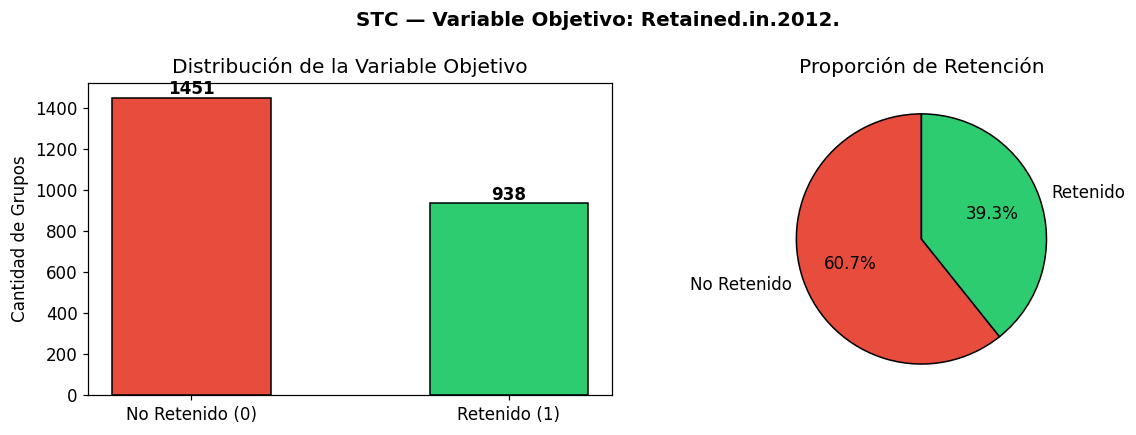

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Conteo
counts = df['Retained.in.2012.'].value_counts()
axes[0].bar(['No Retenido (0)', 'Retenido (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de la Variable Objetivo')
axes[0].set_ylabel('Cantidad de Grupos')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

# Proporción
axes[1].pie(counts.values, labels=['No Retenido', 'Retenido'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proporción de Retención')

plt.suptitle('STC — Variable Objetivo: Retained.in.2012.', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Cuántos valores únicos tiene cada variable de texto
# Esto nos ayuda a decidir cómo codificarlas (Label Encoding vs One-Hot)
cat_cols_preview = df.select_dtypes(include='object').columns

print("=== Cardinalidad de variables categóricas ===\n")
for col in cat_cols_preview:
    uniq = df[col].nunique()
    sample = list(df[col].dropna().unique()[:5])
    print(f"  {col:<35} {uniq:>3} valores únicos   → {sample}")

=== Cardinalidad de variables categóricas ===

  Program.Code                         28 valores únicos   → ['HS', 'HC', 'HD', 'HN', 'SG']
  Group.State                          54 valores únicos   → ['CA', 'AZ', 'FL', 'VA', 'LA']
  Travel.Type                           4 valores únicos   → ['A', 'B', 'T', 'N']
  Special.Pay                           3 valores únicos   → ['CP', 'FR', 'SA']
  Poverty.Code                          6 valores únicos   → ['B', 'C', 'D', 'A', 'E']
  Region                                6 valores únicos   → ['Southern California', 'Other', 'Houston', 'Northern California', 'Dallas']
  School.Type                           4 valores únicos   → ['PUBLIC', 'CHD', 'Catholic', 'Private non-Christian']
  MDR.Low.Grade                        12 valores únicos   → ['K', '7', '6', '10', '9']
  Income.Level                         22 valores únicos   → ['Q', 'A', 'O', 'C', 'I']
  SPR.Product.Type                      6 valores únicos   → ['CA History', 'East Coast', '

In [9]:
# Resumen estadístico de variables numéricas
# Permite detectar rangos extraños, valores mínimos/máximos anómalos y skewness
display(df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std']))

,count,mean,std,min,25%,50%,75%,max
ID,2389.000000,1195.000000,689.789219,1.000000,598.000000,1195.000000,1792.000000,2389.000000
From.Grade,2262.000000,7.268347,1.388350,3.000000,7.000000,8.000000,8.000000,12.000000
To.Grade,2239.000000,7.912908,1.558226,3.000000,8.000000,8.000000,8.000000,12.000000
Is.Non.Annual.,2389.000000,0.154039,0.361062,0.000000,0.000000,0.000000,0.000000,1.000000
Days,2389.000000,4.575136,1.432128,1.000000,4.000000,5.000000,5.000000,12.000000
Departure.Date,2389.000000,40670.764337,35.217643,40557.000000,40642.000000,40680.000000,40701.000000,40724.000000
Return.Date,2389.000000,40674.498535,35.243691,40557.000000,40645.000000,40683.000000,40704.000000,40729.000000
Deposit.Date,2389.000000,40475.821264,37.906251,40081.000000,40466.000000,40479.000000,40487.000000,40846.000000
Tuition,2389.000000,1615.217664,645.096047,79.000000,1174.000000,1700.000000,2048.000000,4200.000000
FRP.Active,2389.000000,16.867727,16.942782,0.000000,6.000000,12.000000,23.000000,257.000000


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:07 -> (00:00 left)


Report reporte_sweetviz_STC.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
✅ Reporte guardado como 'reporte_sweetviz_STC.html'



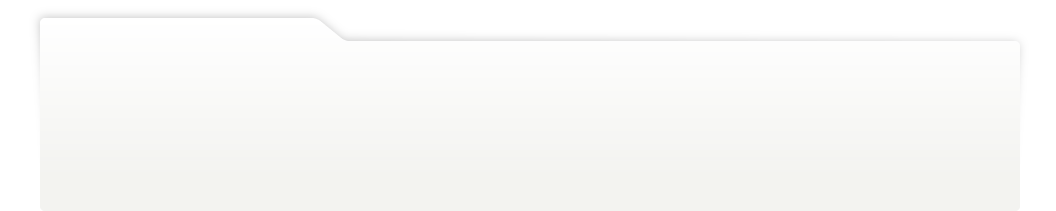
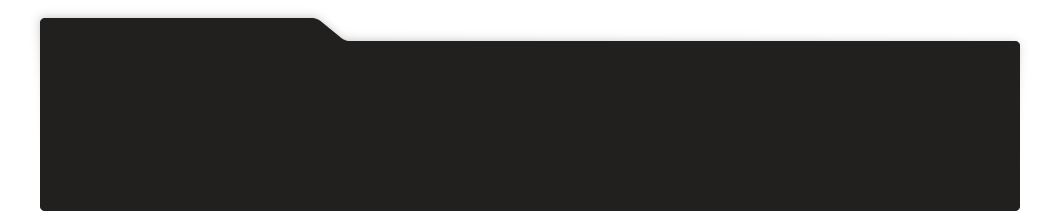
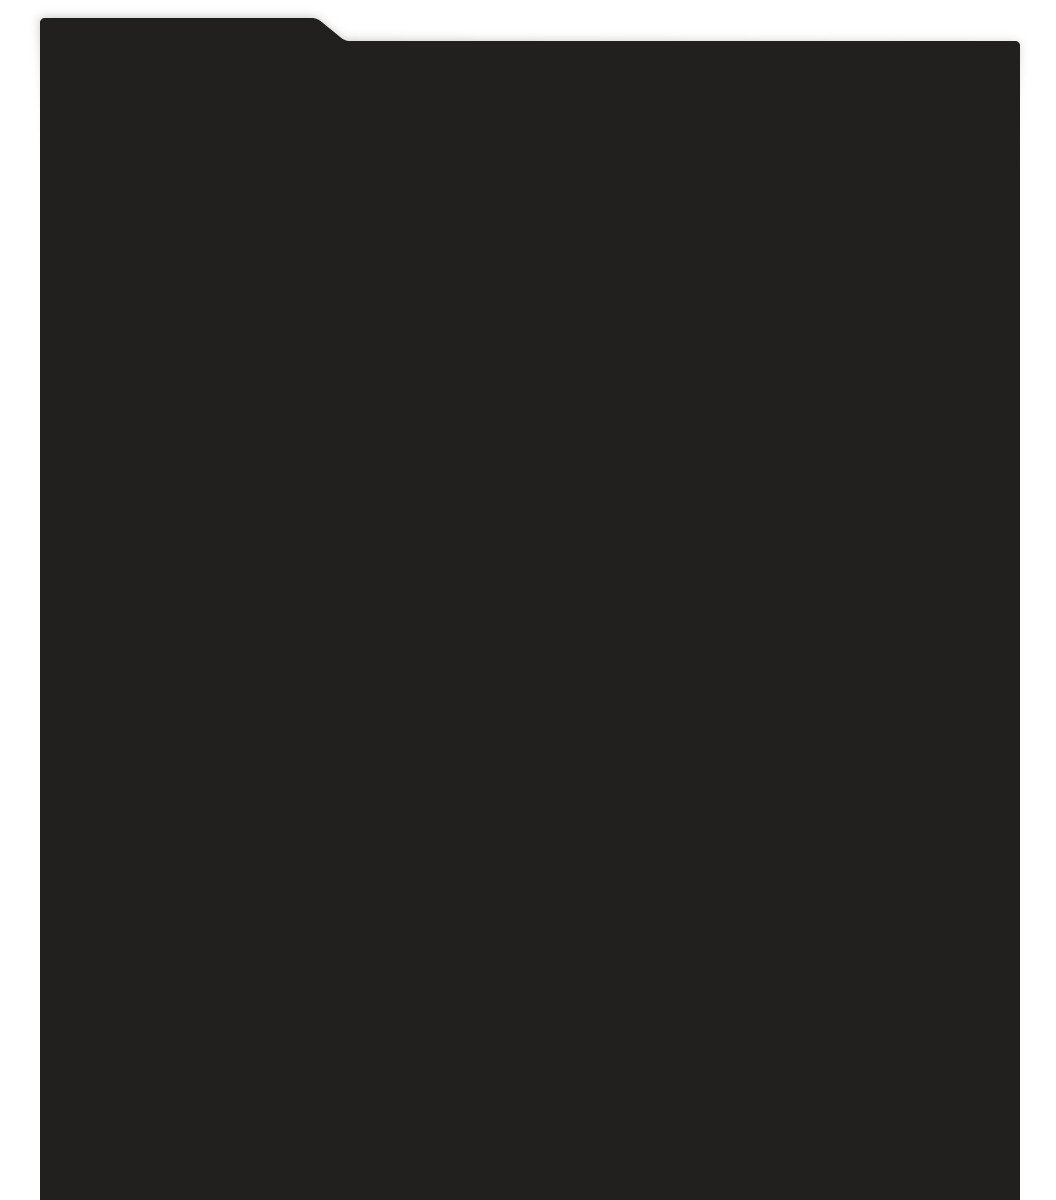
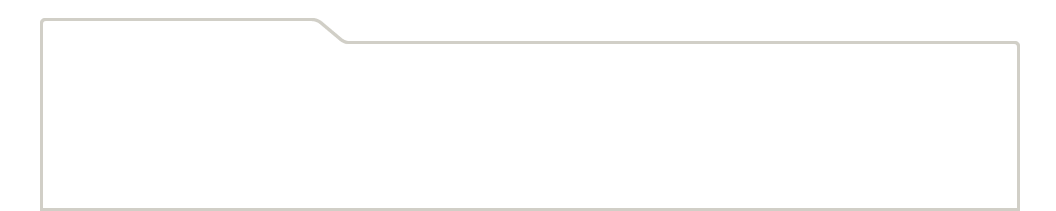
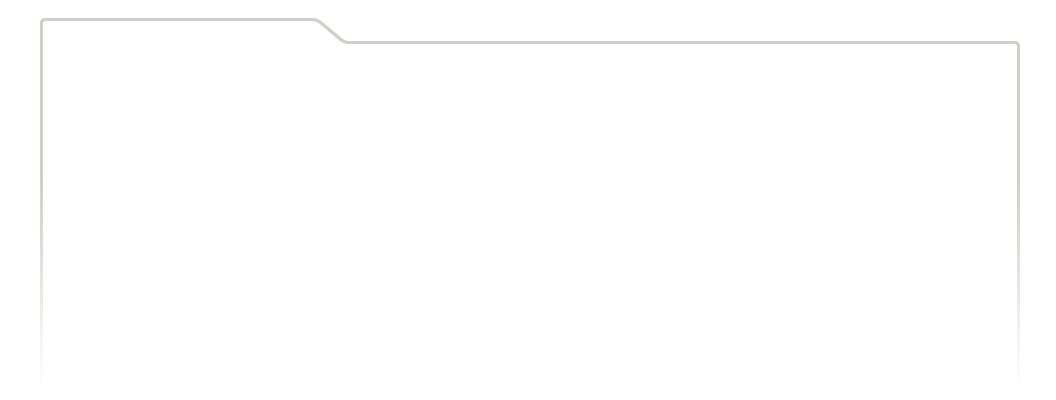
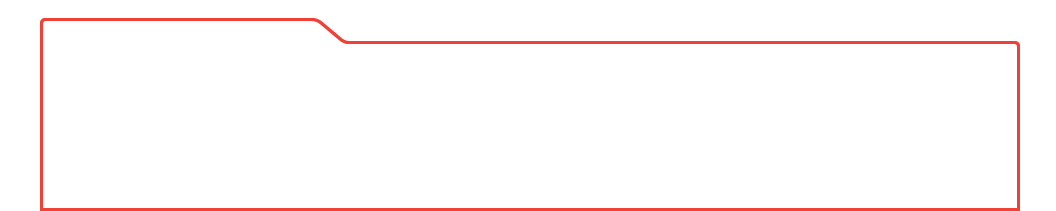
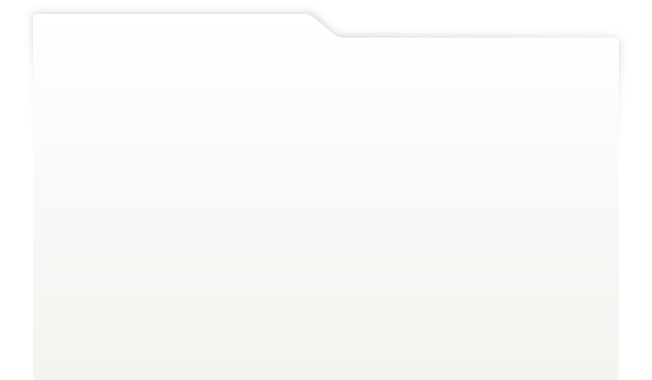
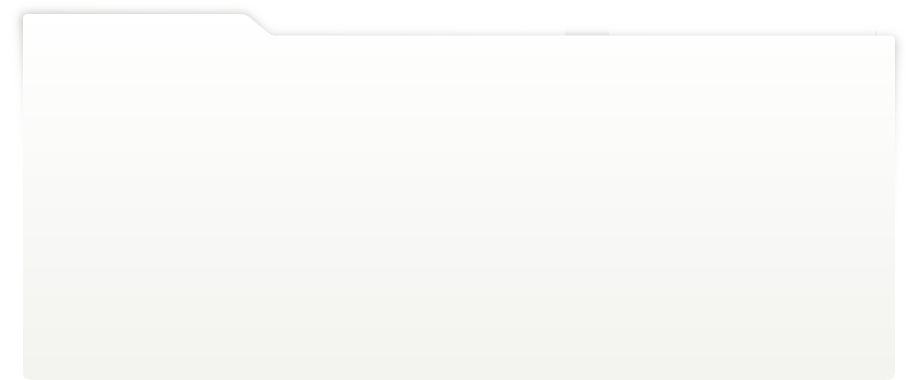
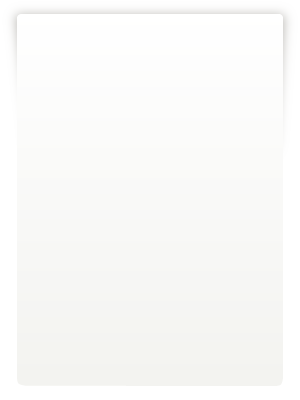
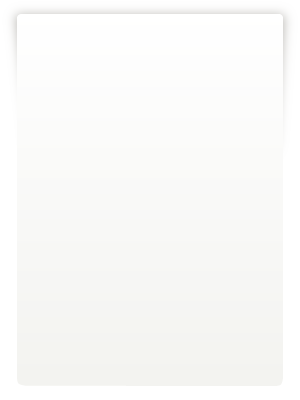
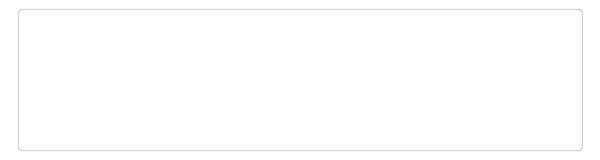
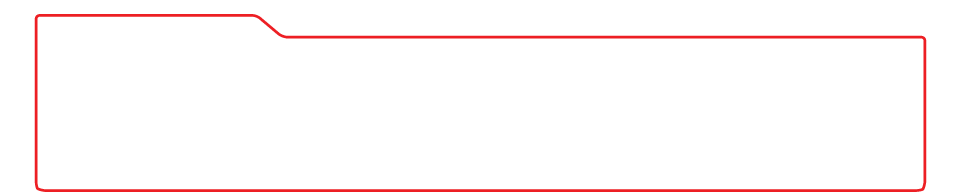
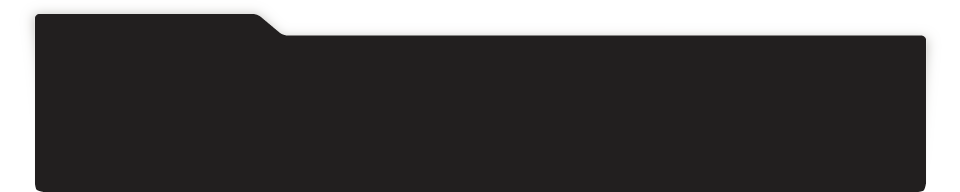
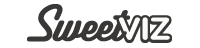
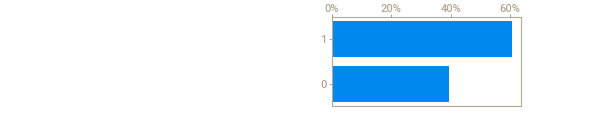
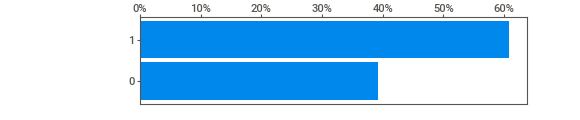
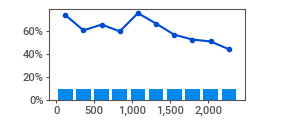
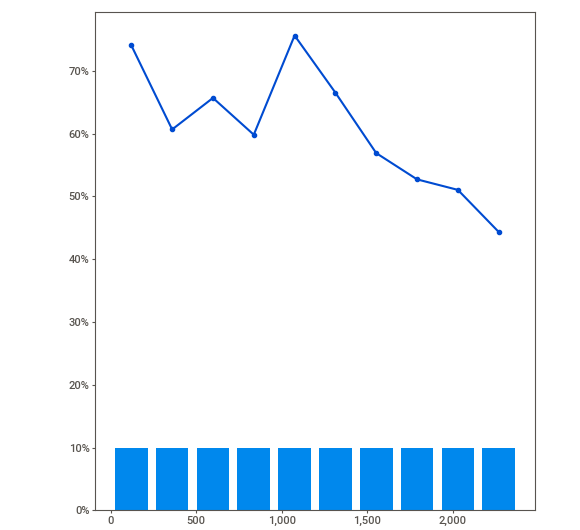
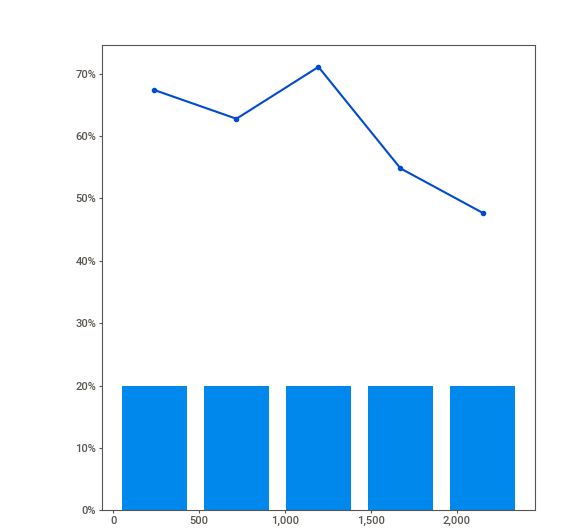
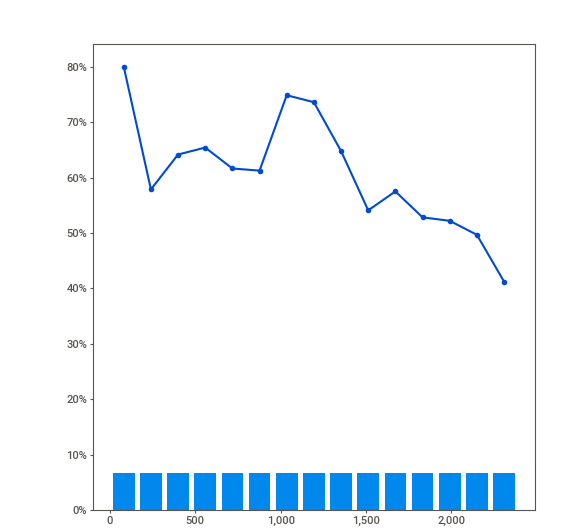
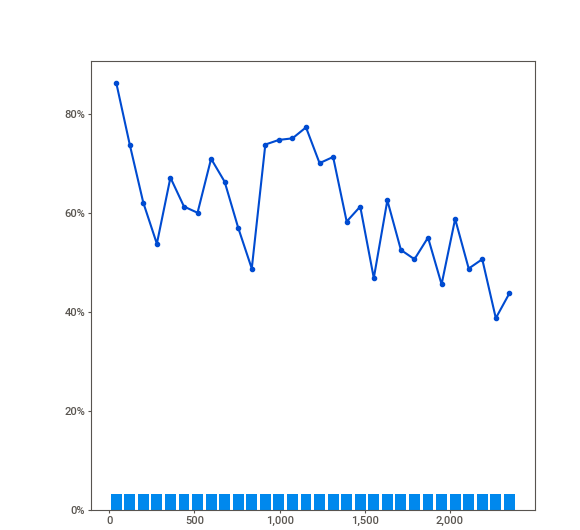
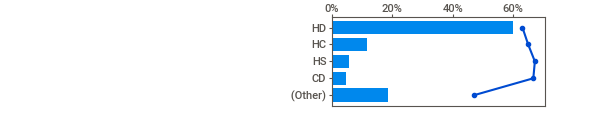
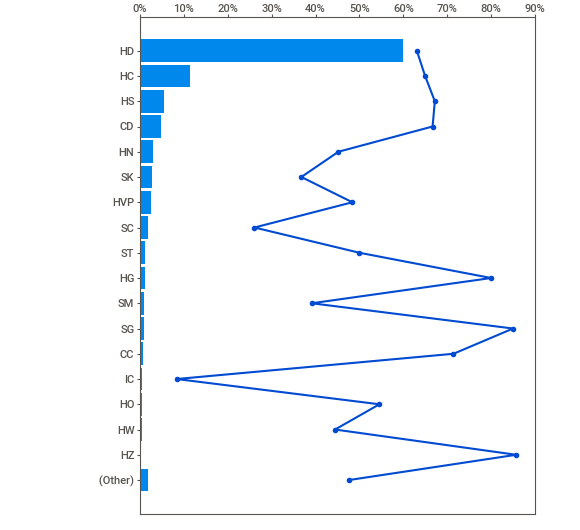
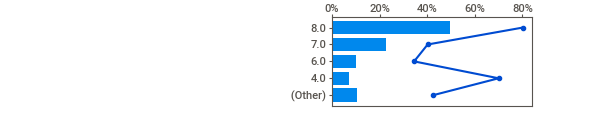
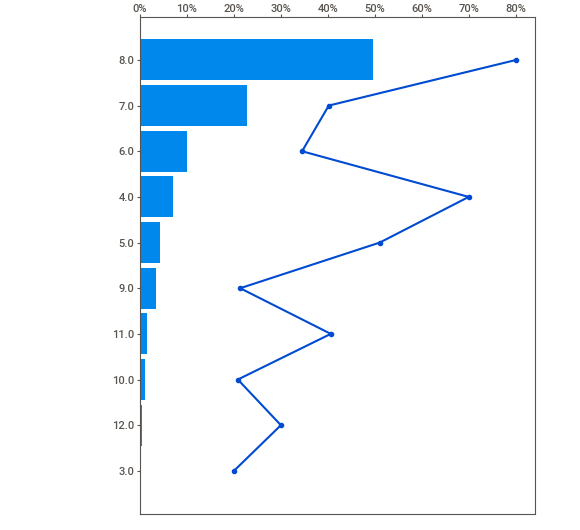
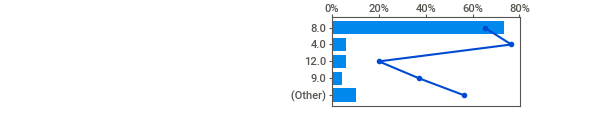
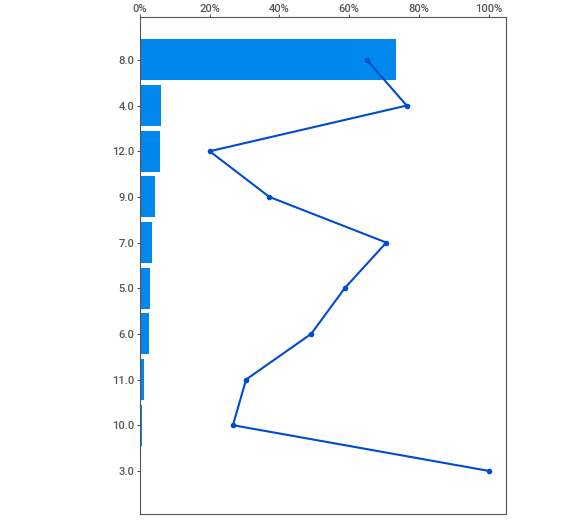
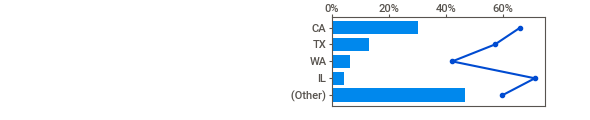
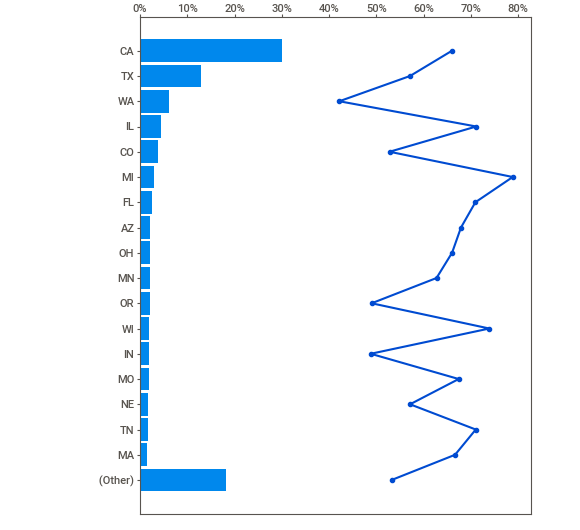
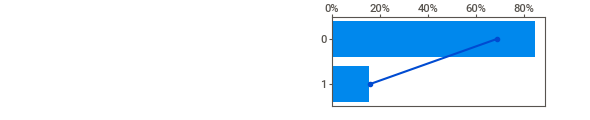
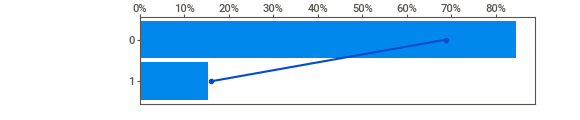
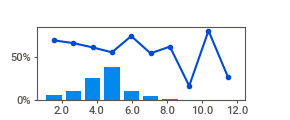
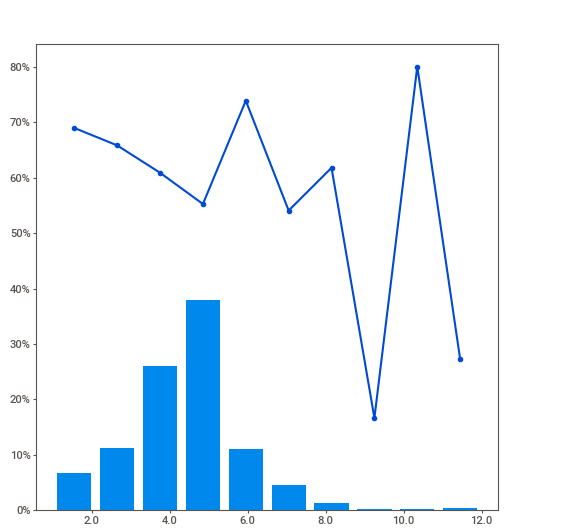
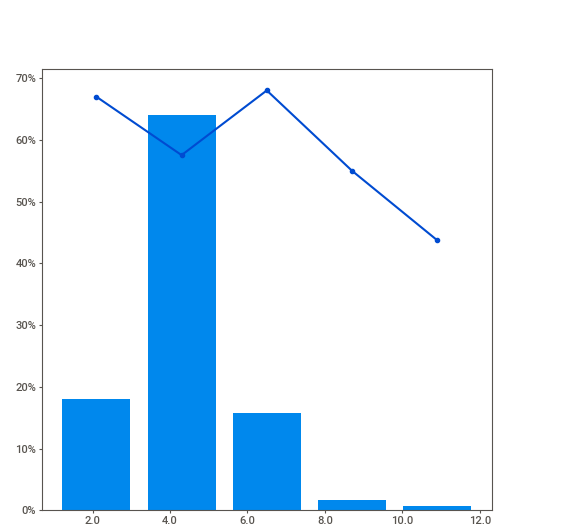
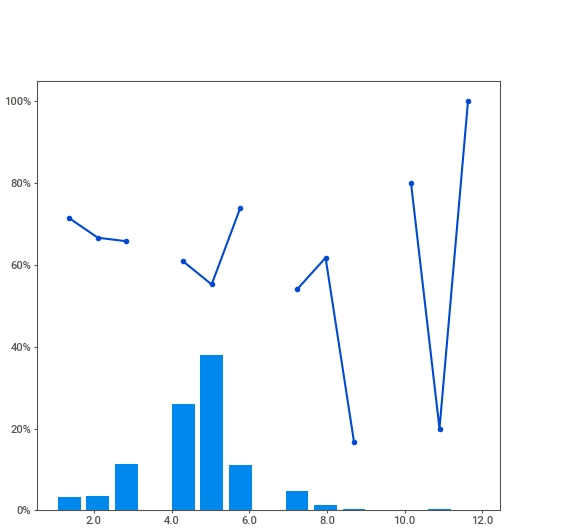
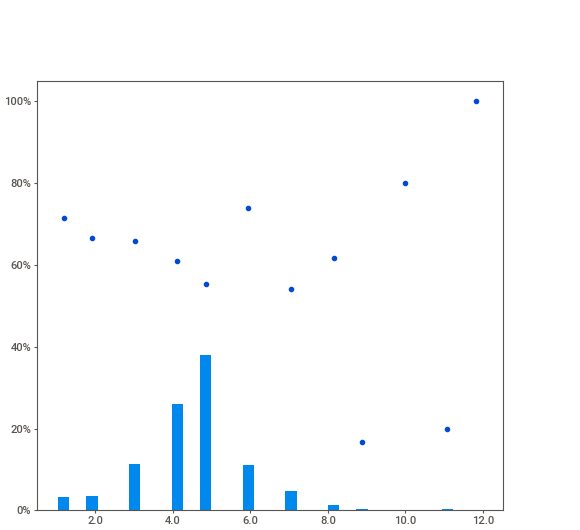
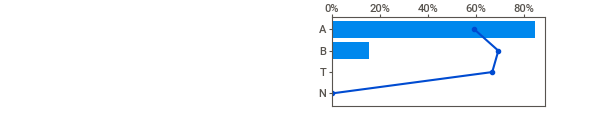
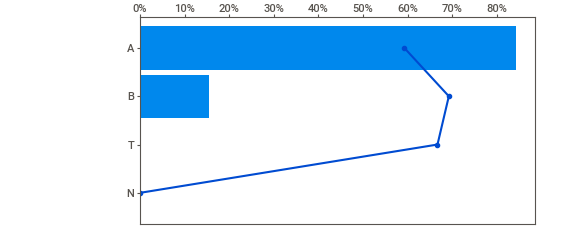
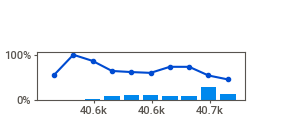
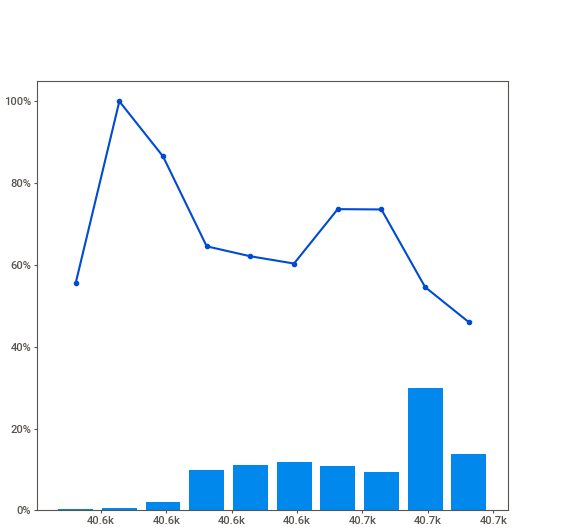
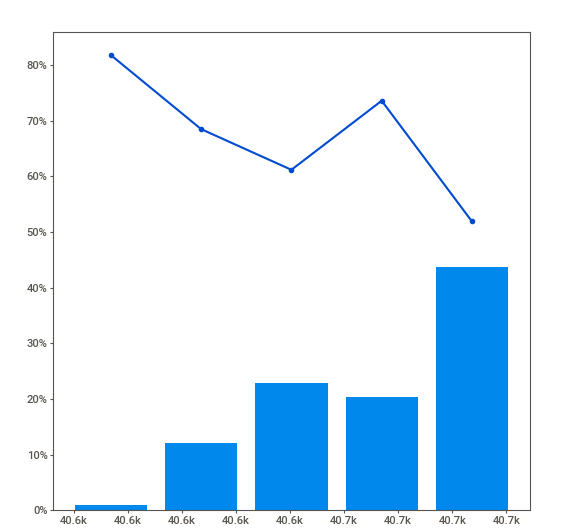
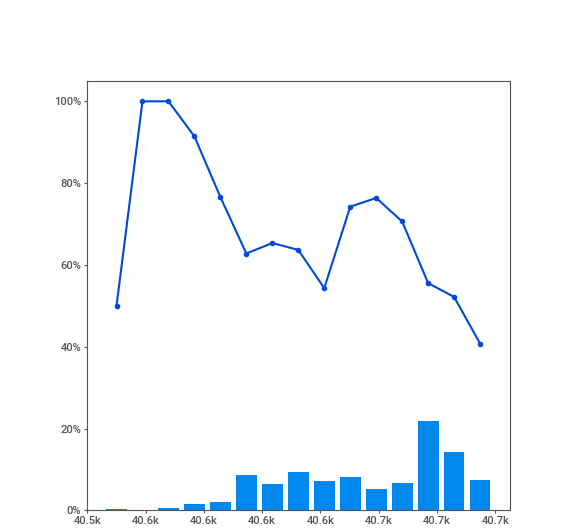
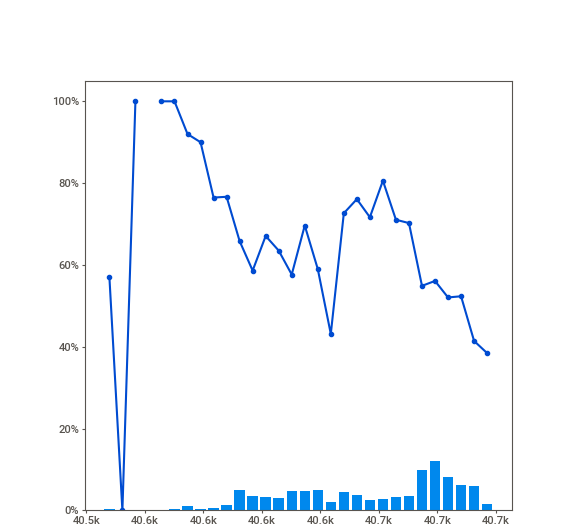
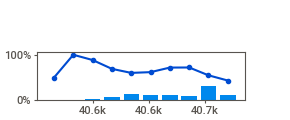
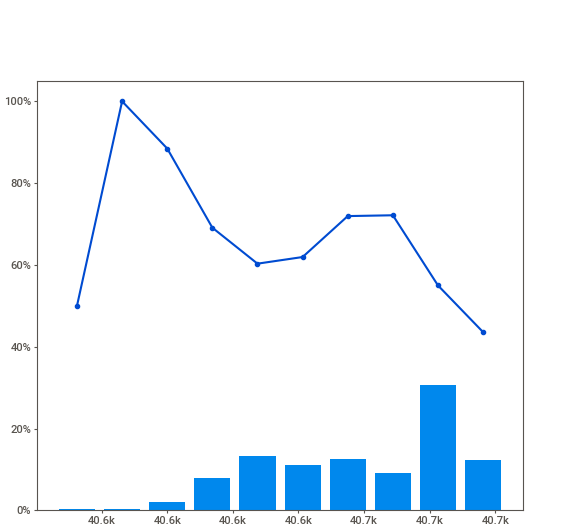
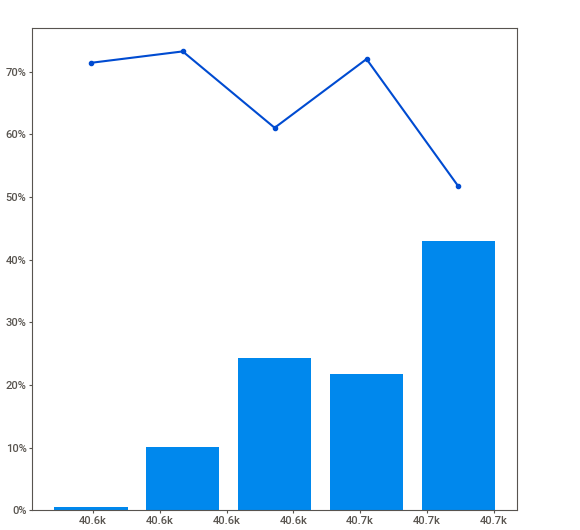
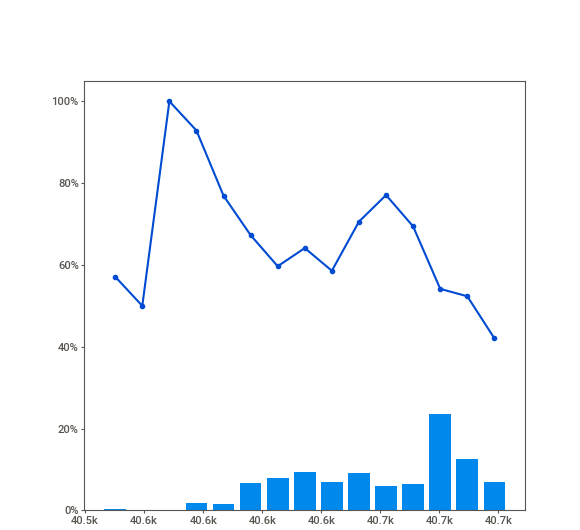
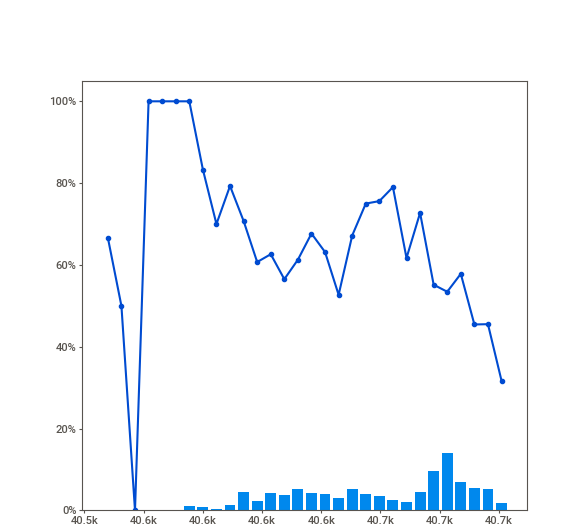
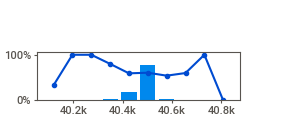
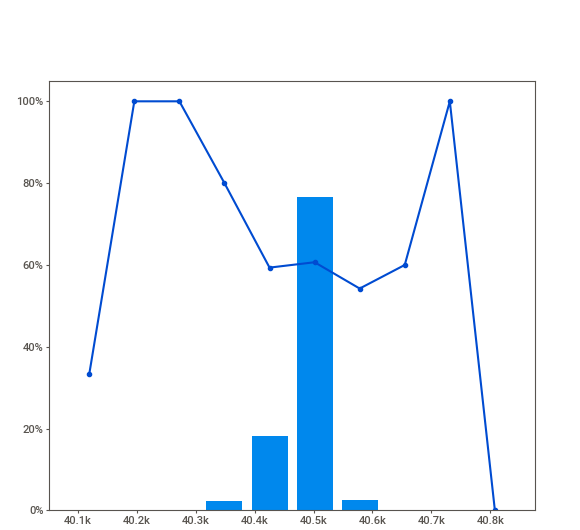
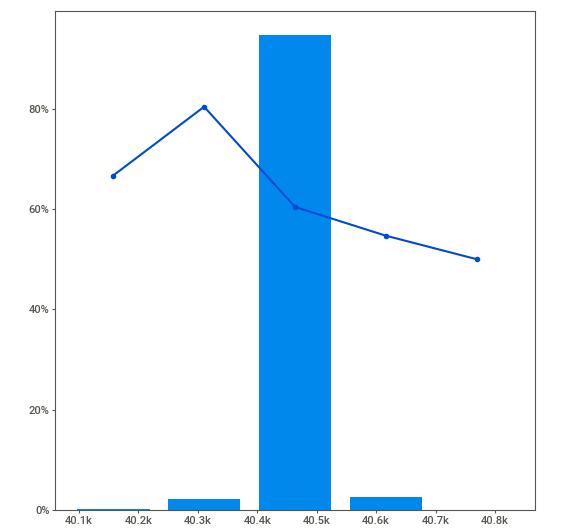
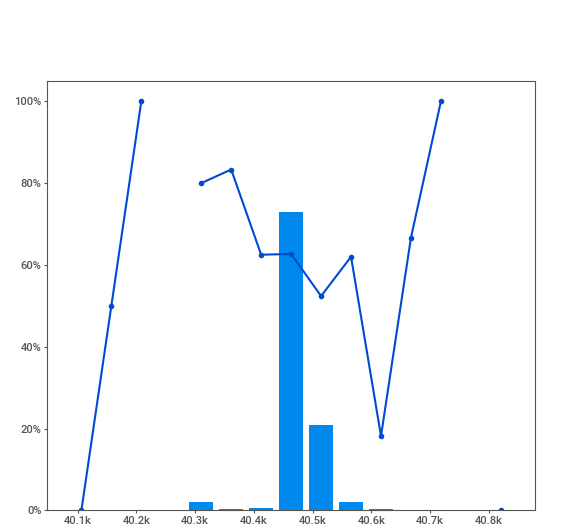
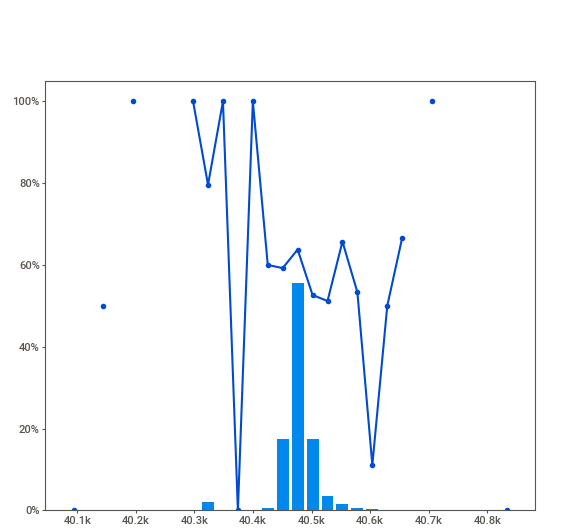
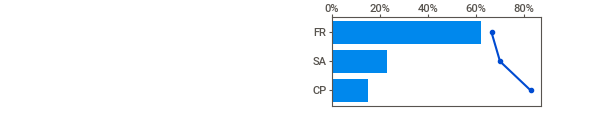
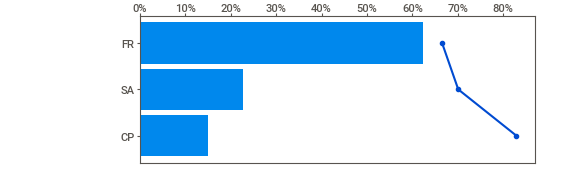
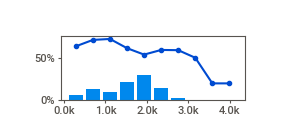
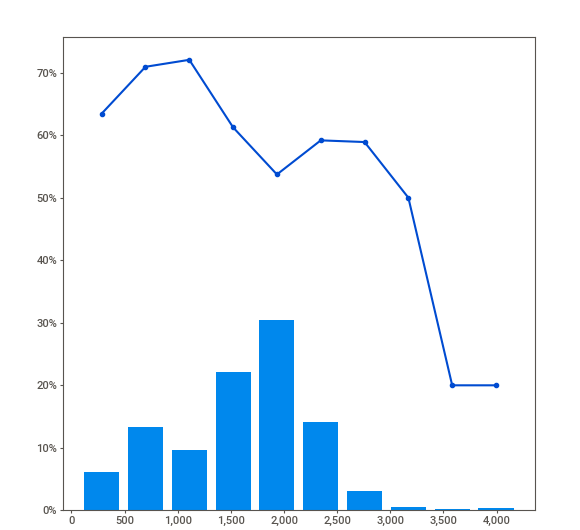
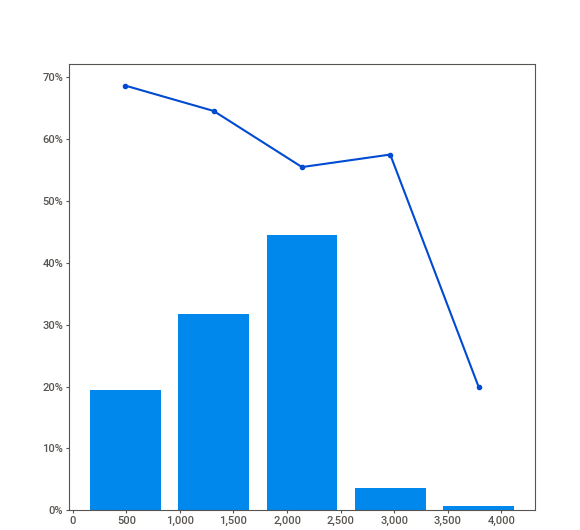
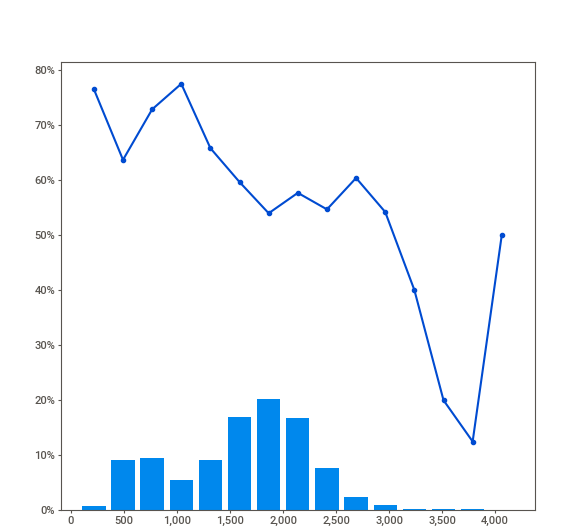
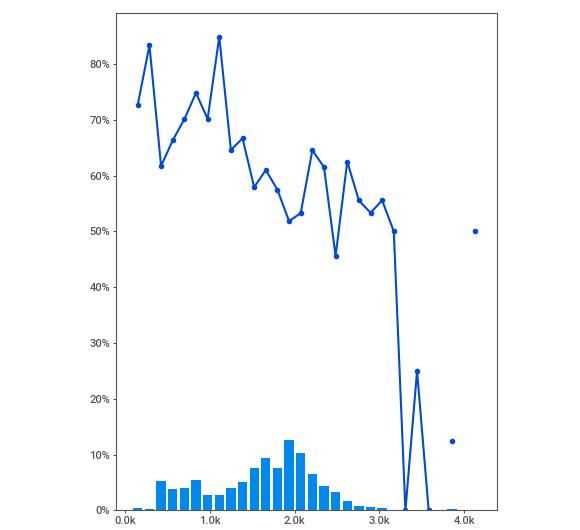
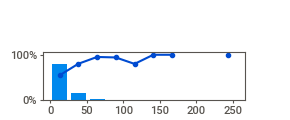
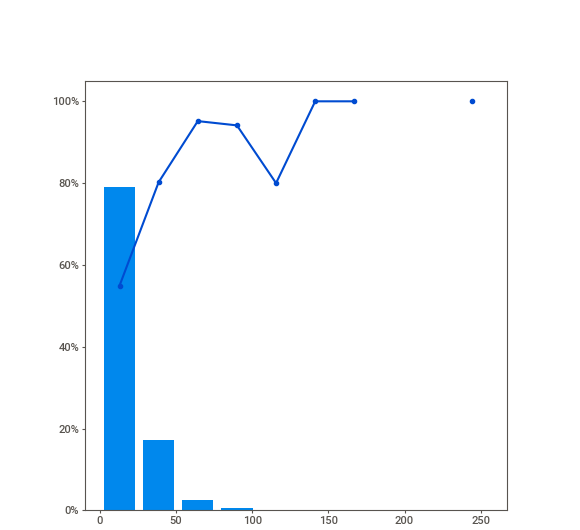
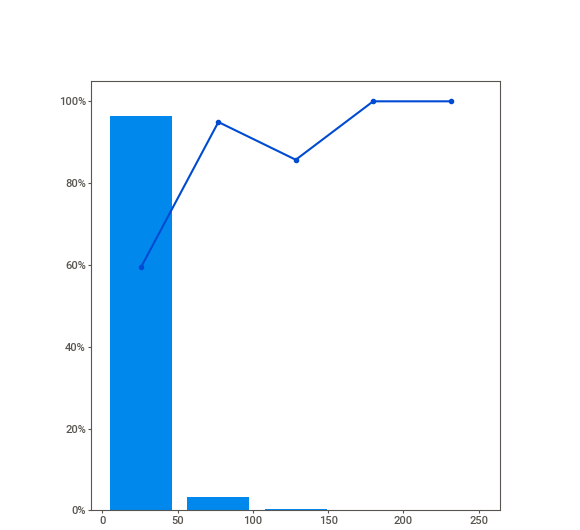
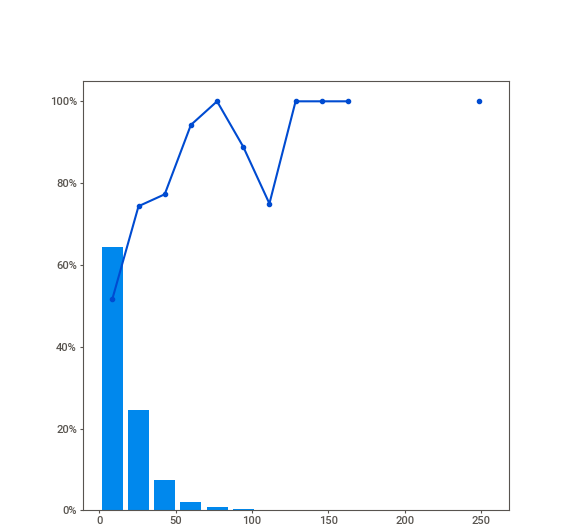
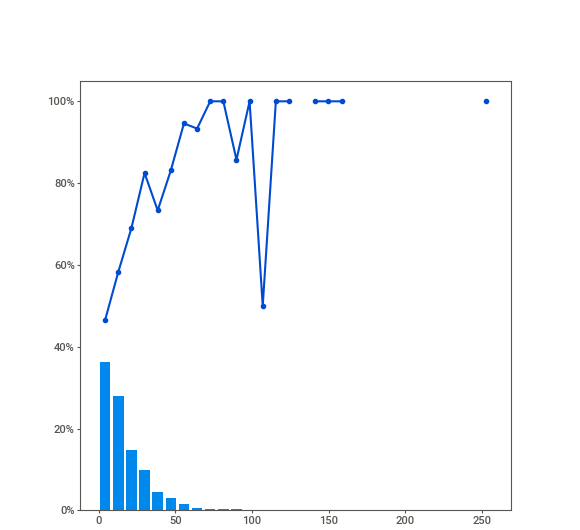
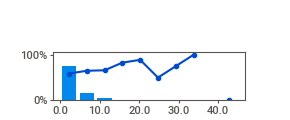
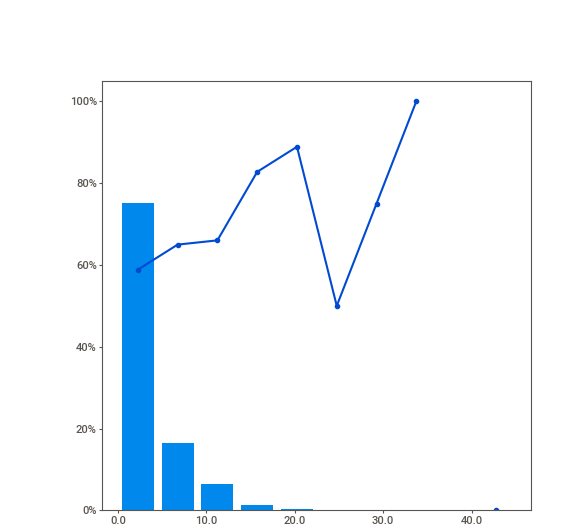
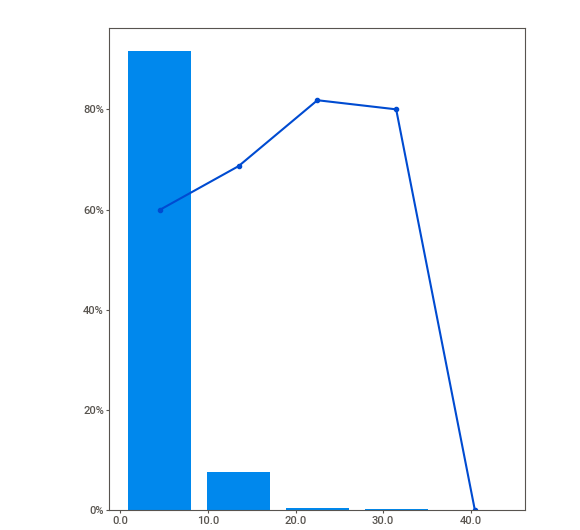
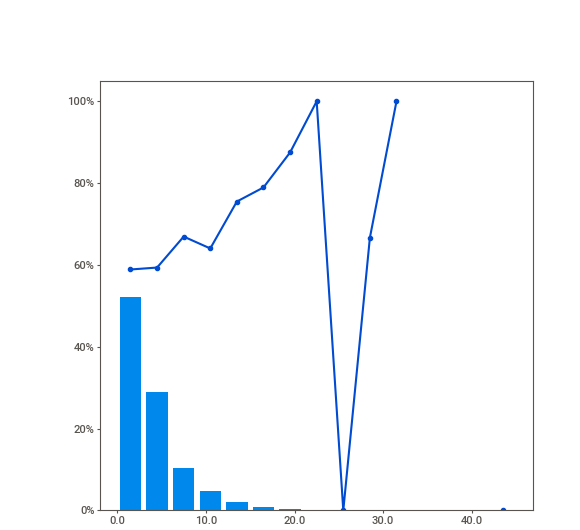
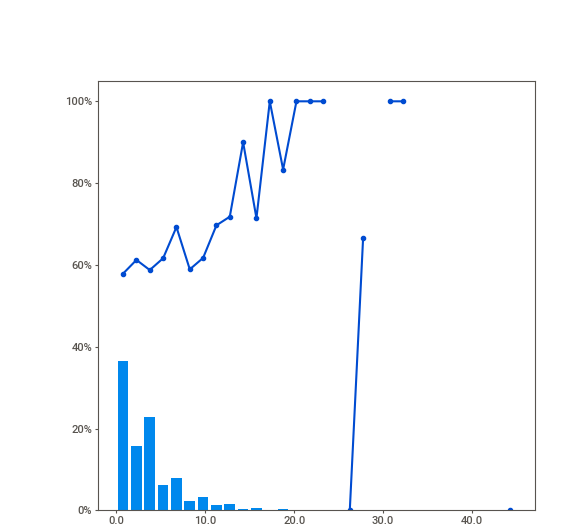
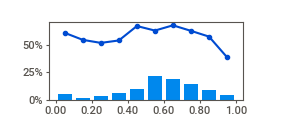
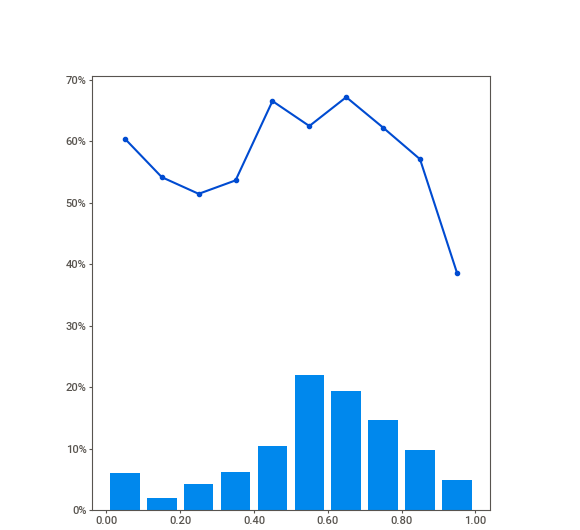
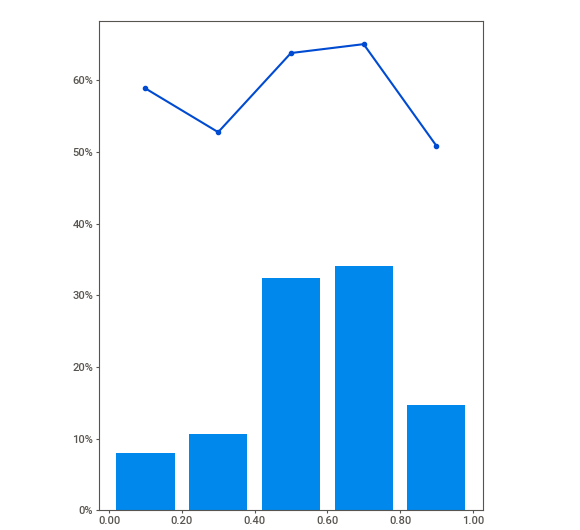
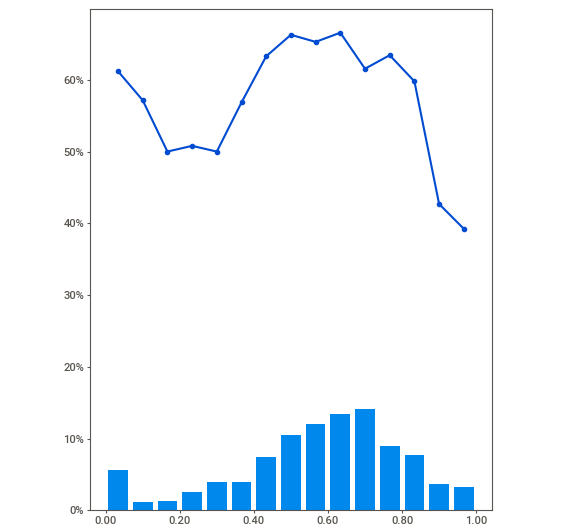
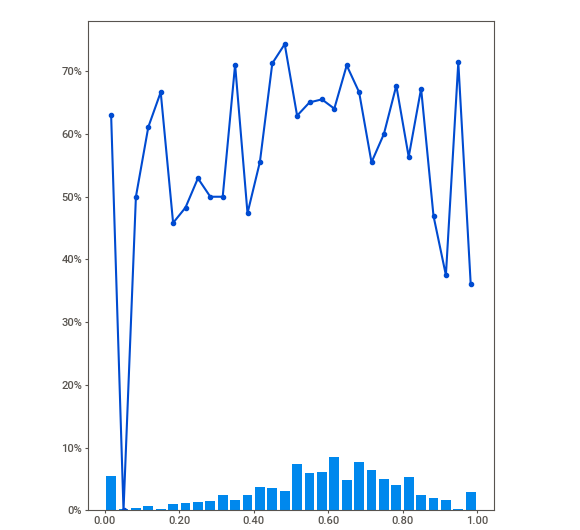
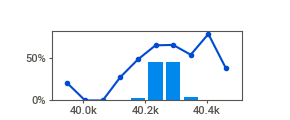
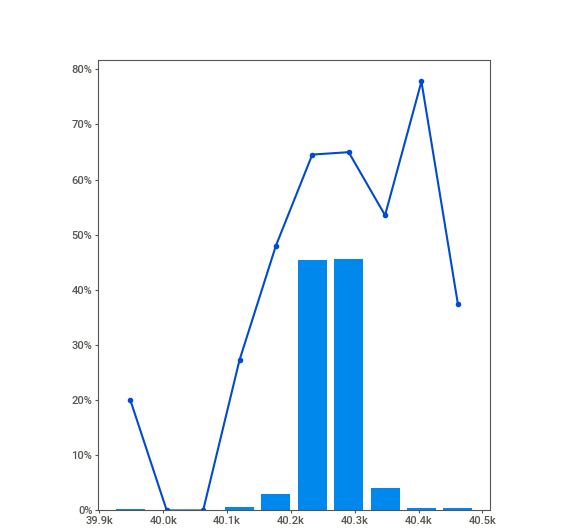
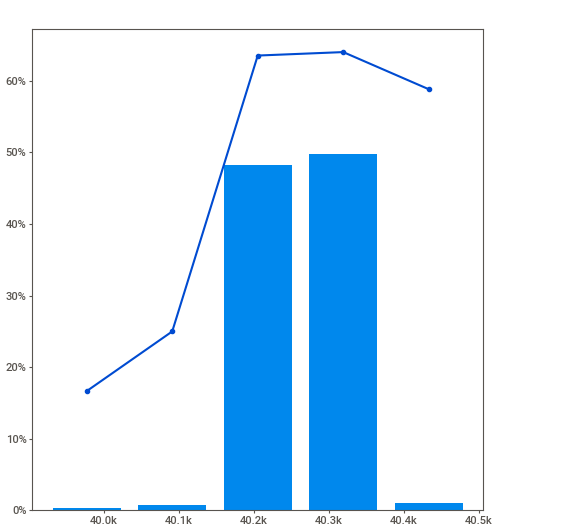
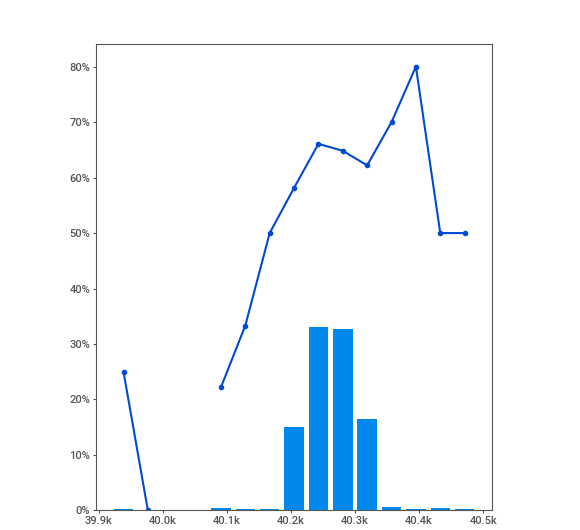
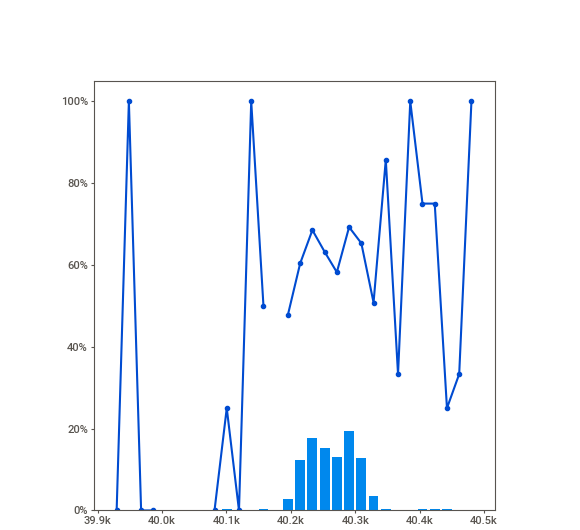
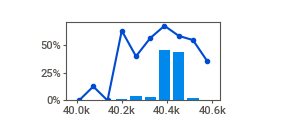
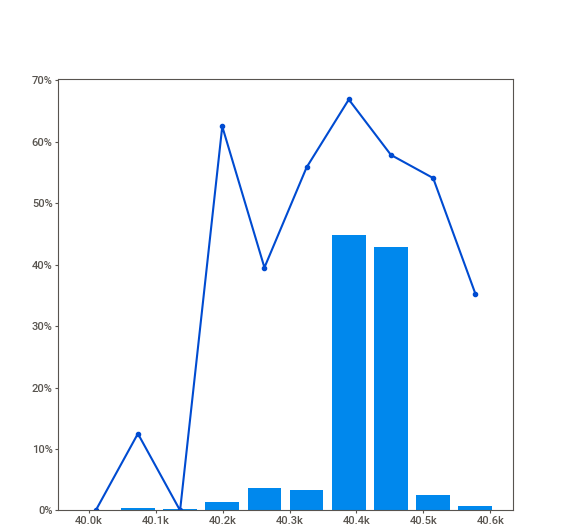
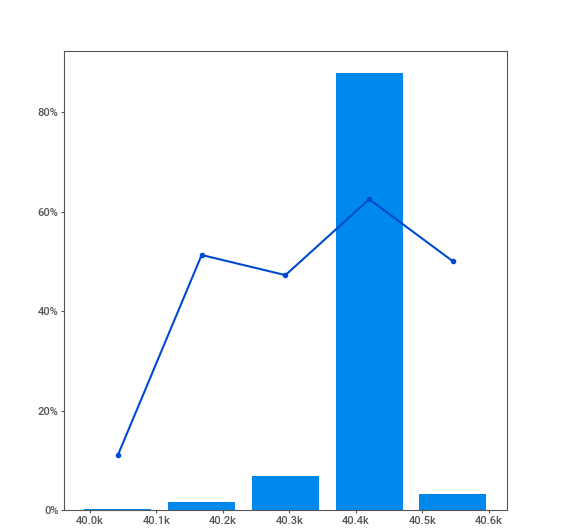
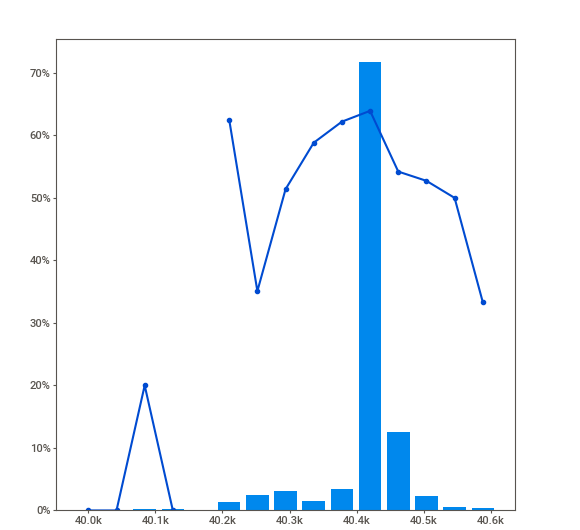
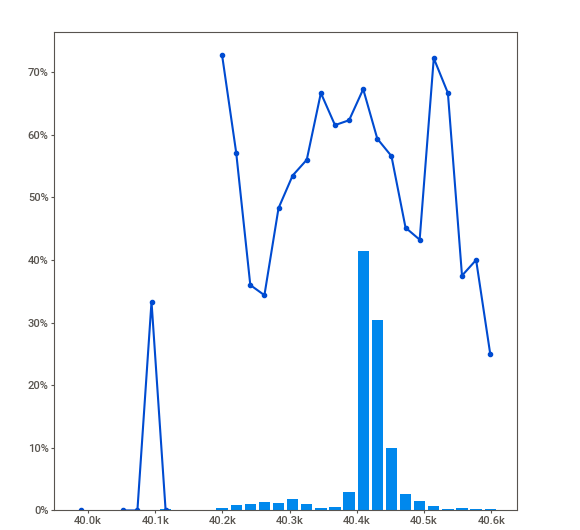
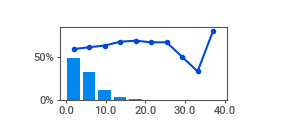
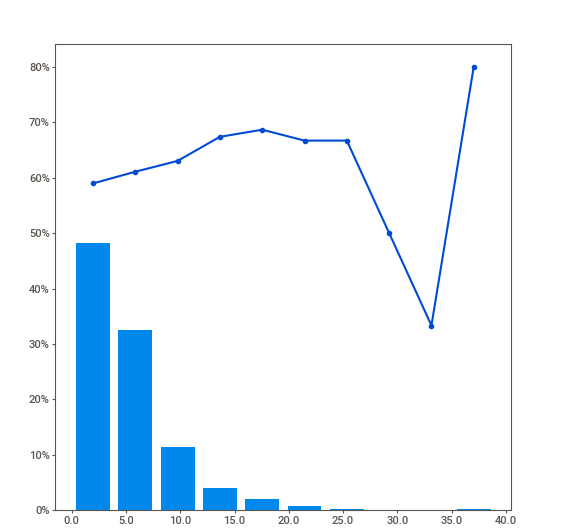
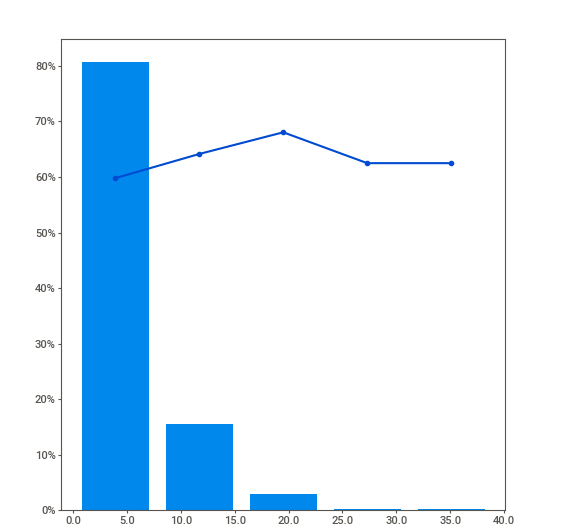
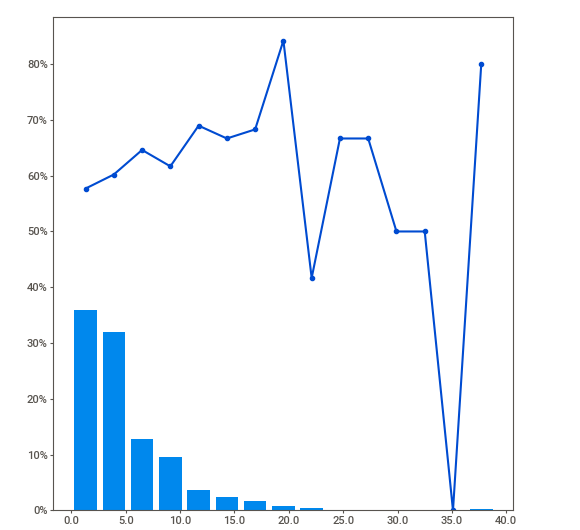
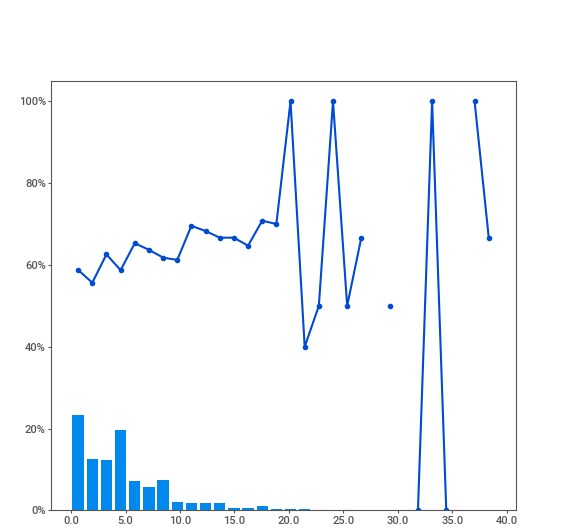
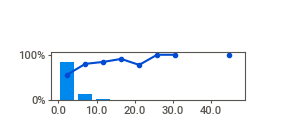
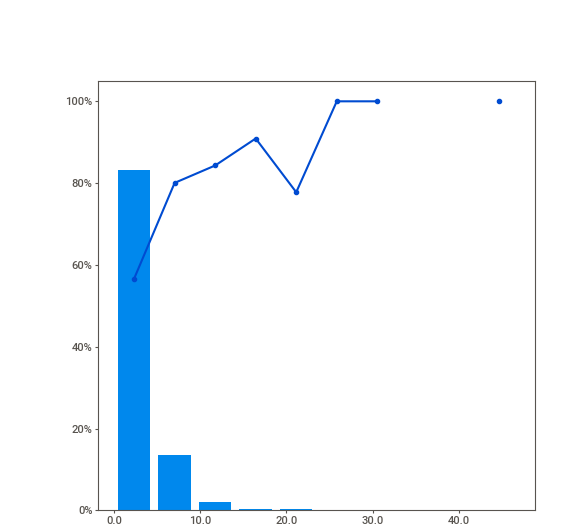
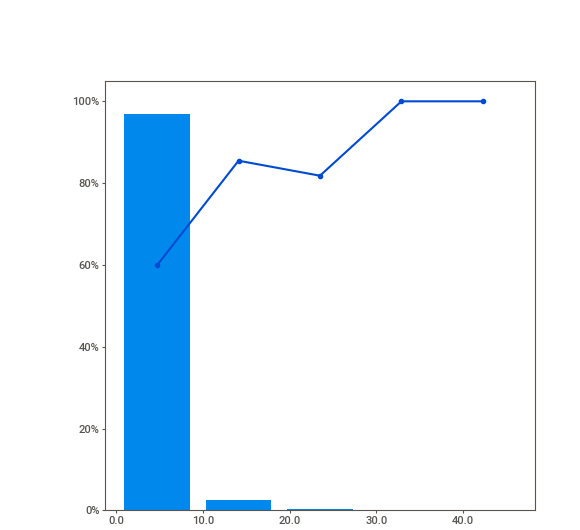
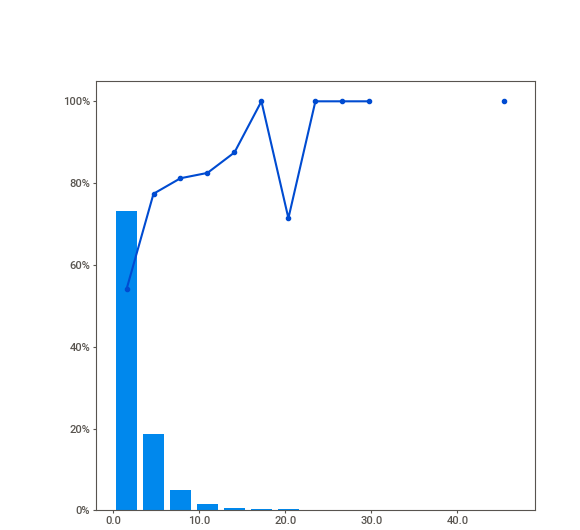
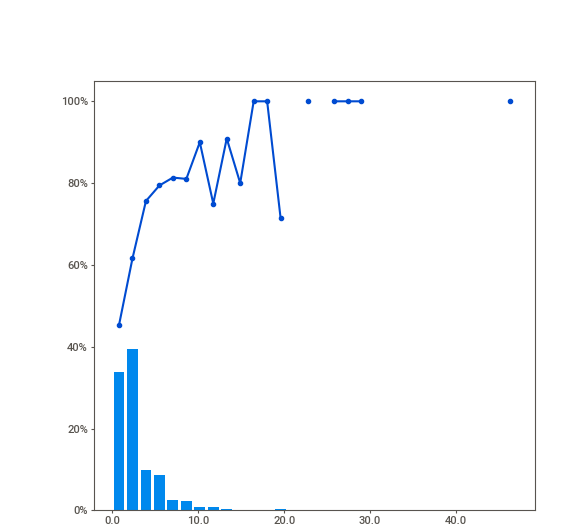
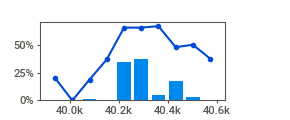
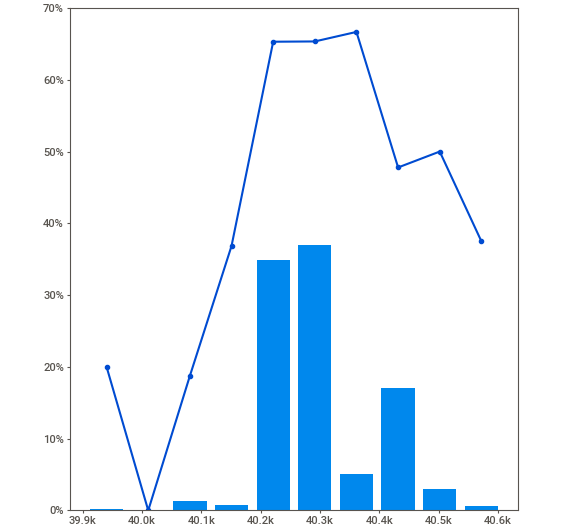
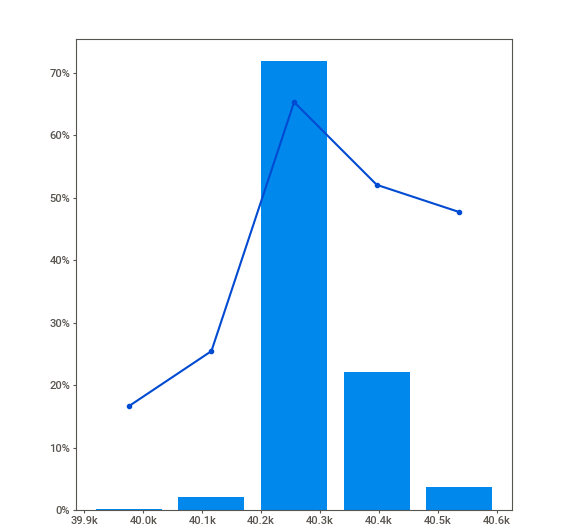
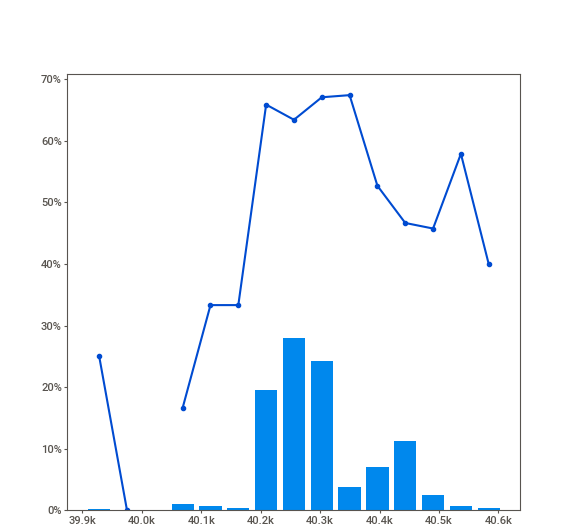
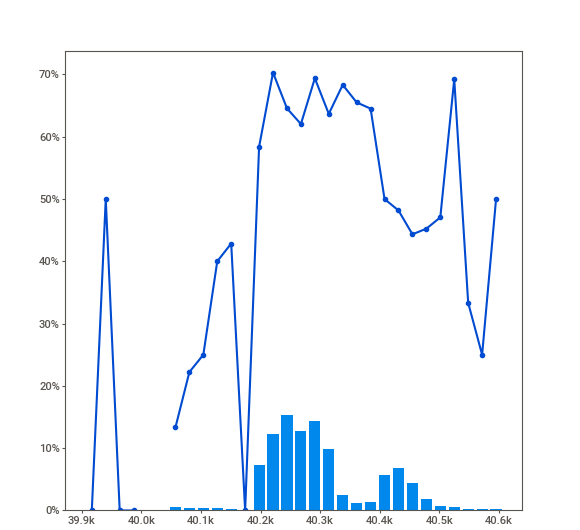
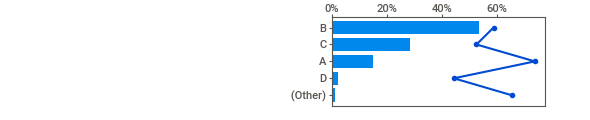
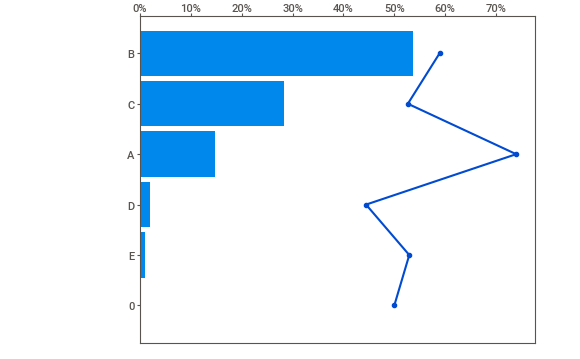
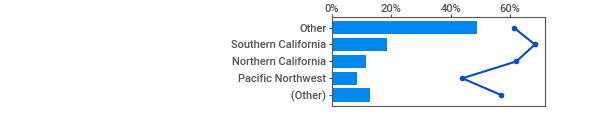
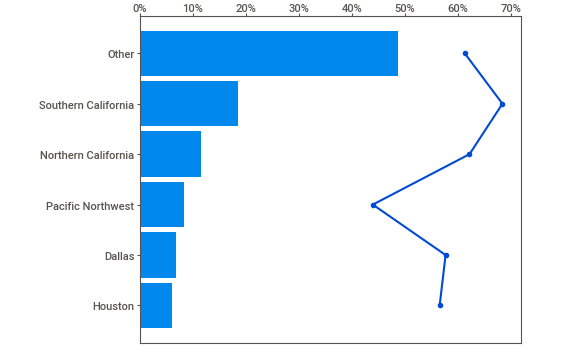
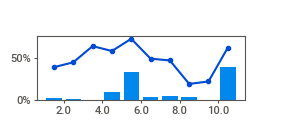
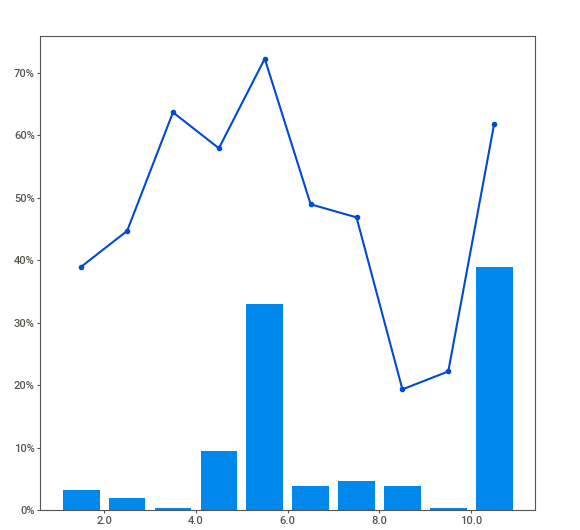
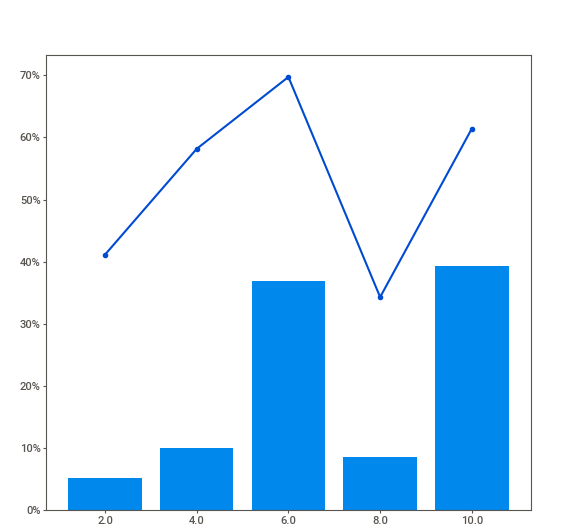
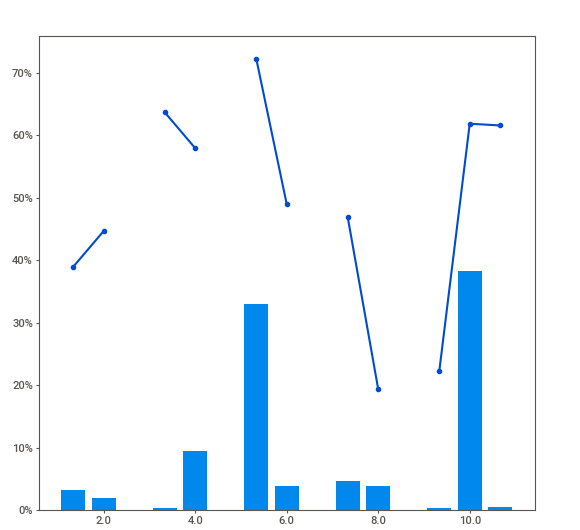
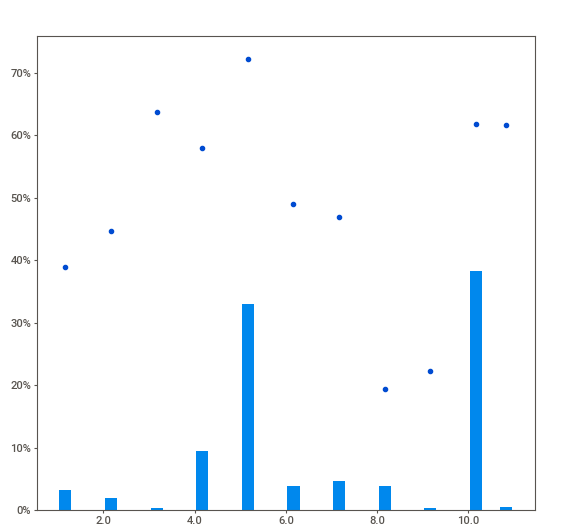
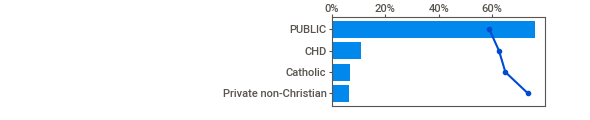
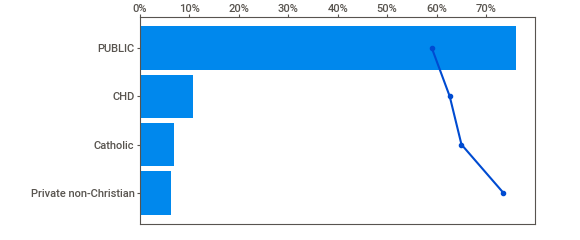
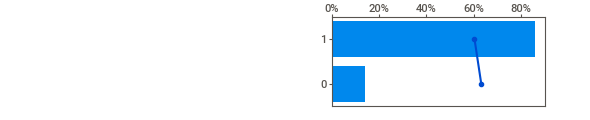
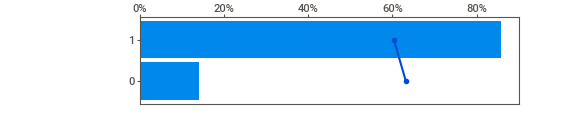
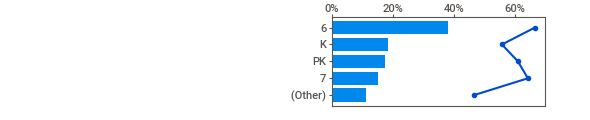
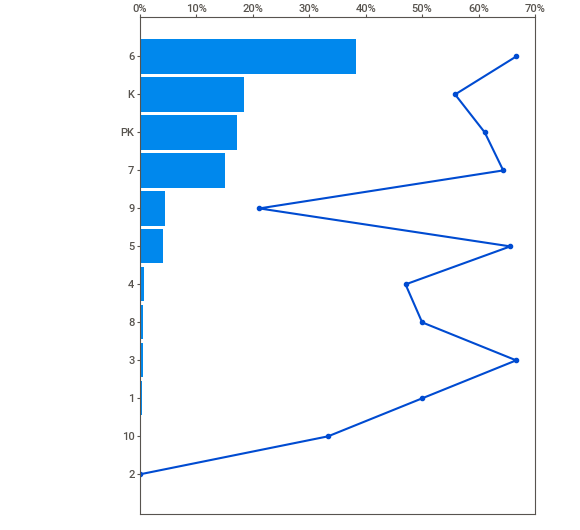
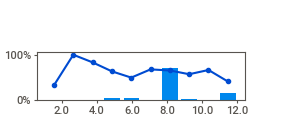
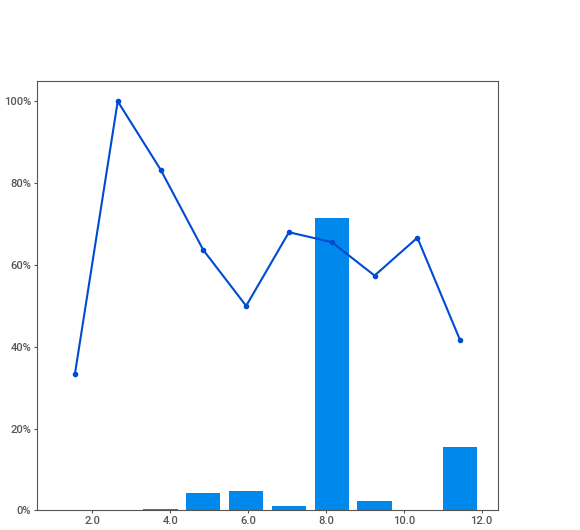
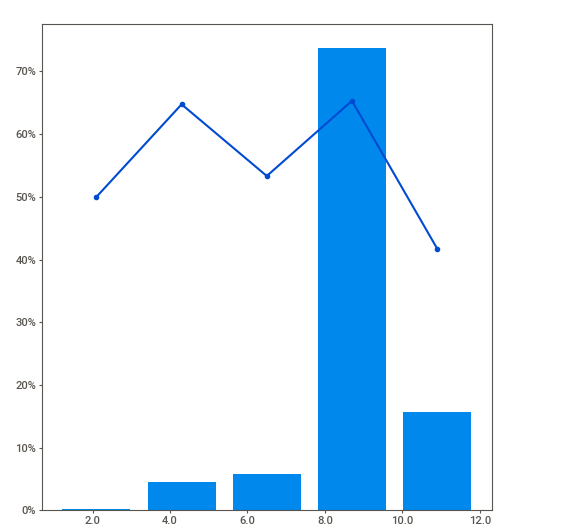
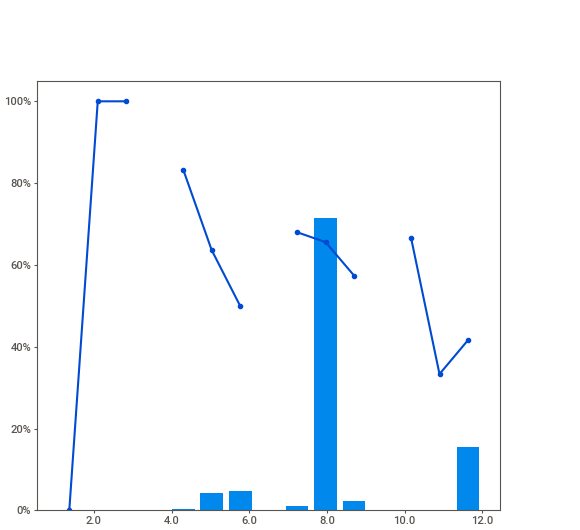
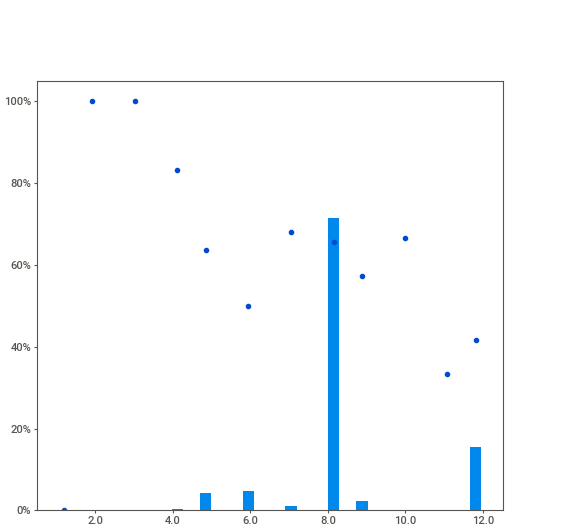
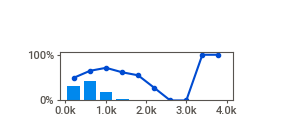
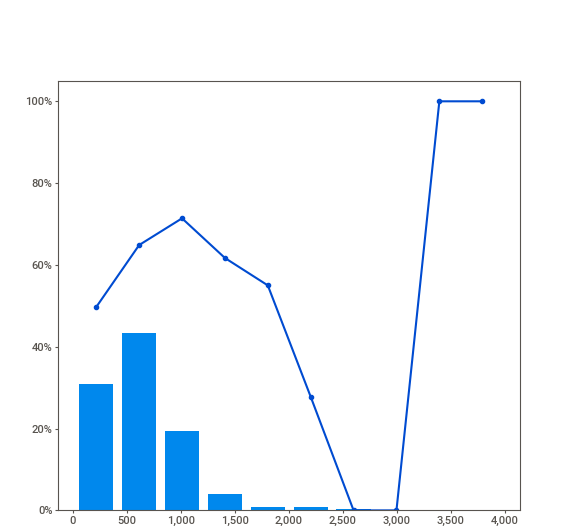
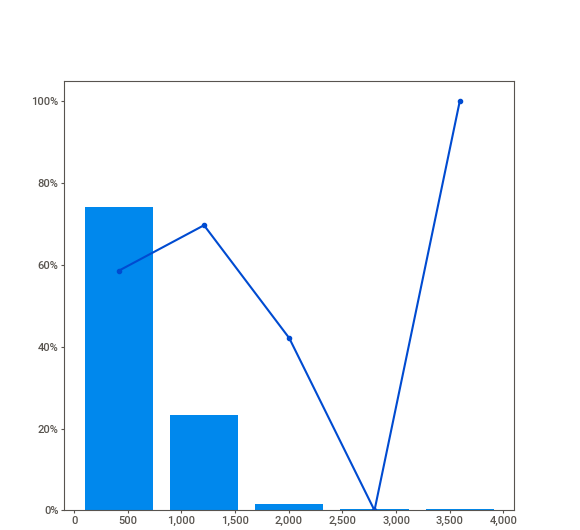
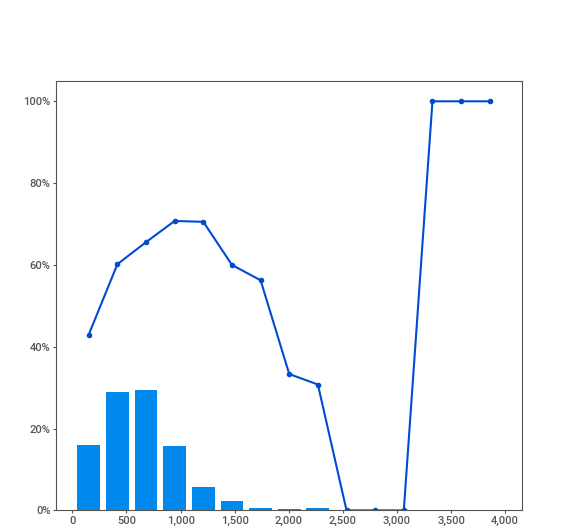
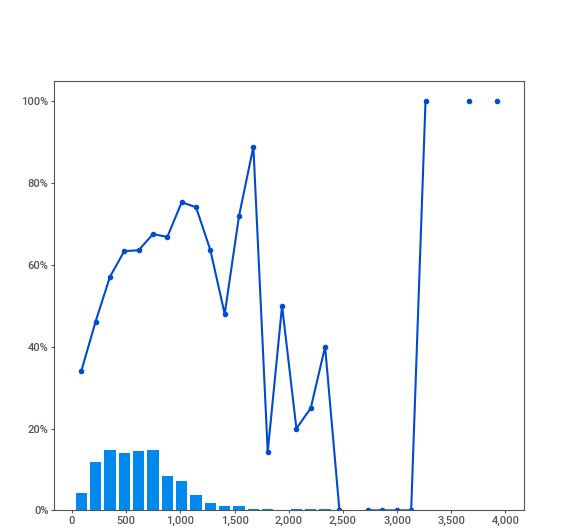
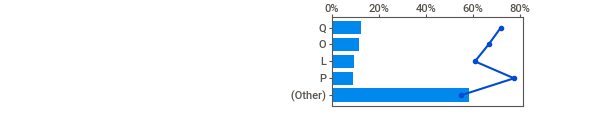
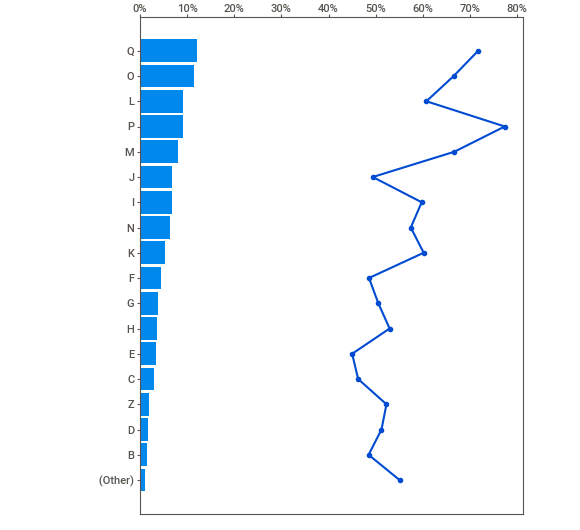
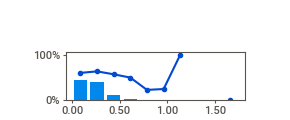
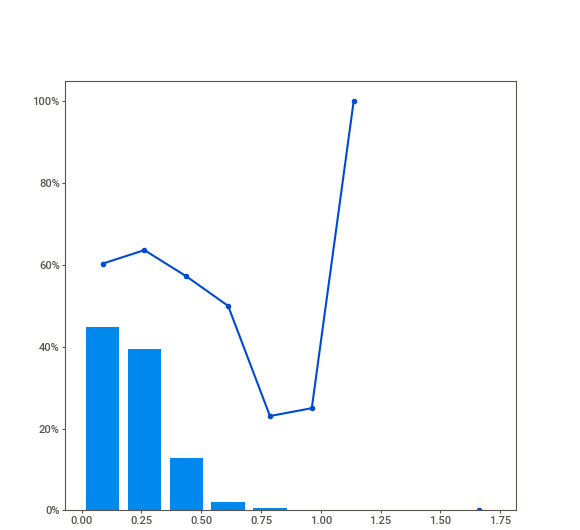
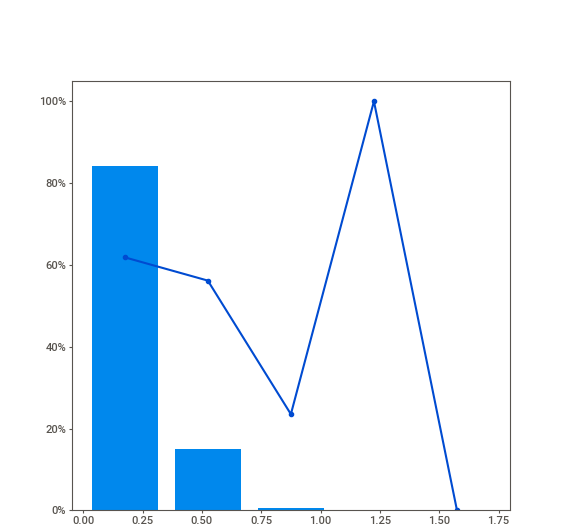
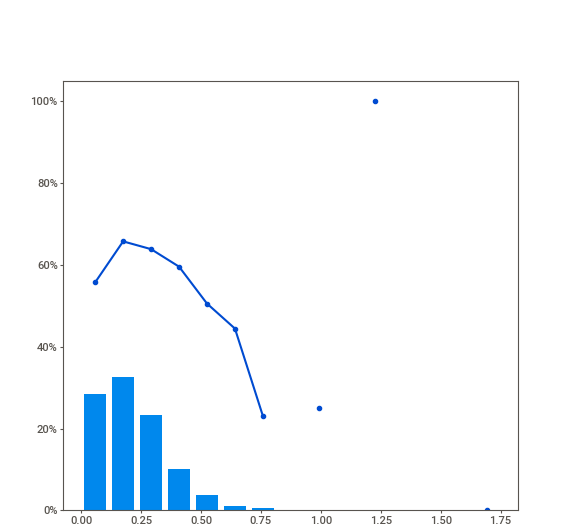
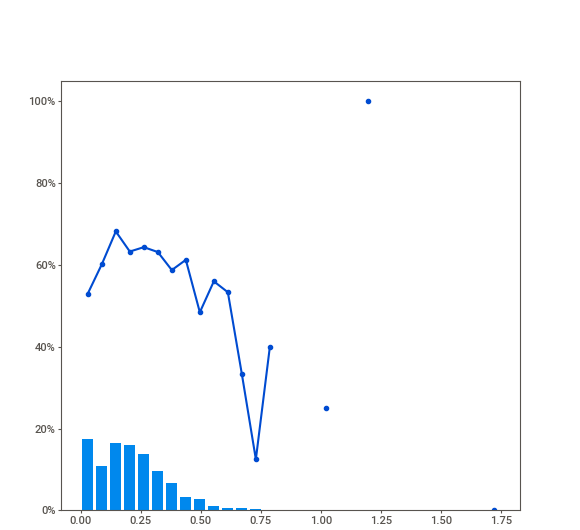
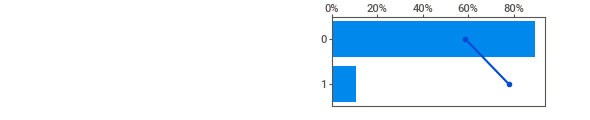
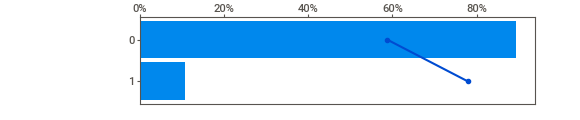
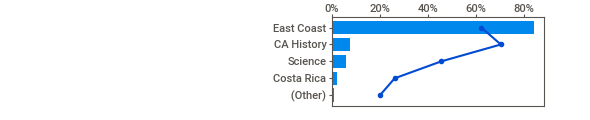
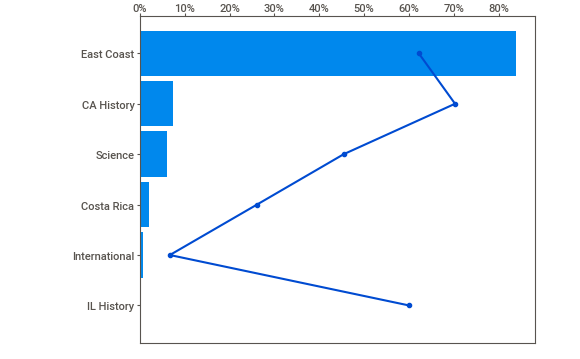
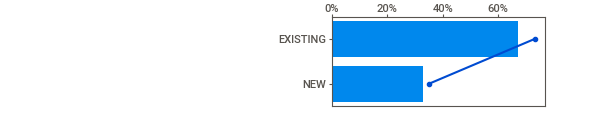
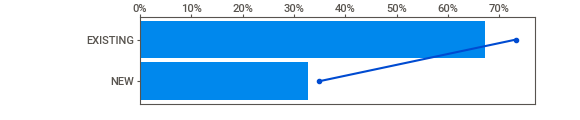
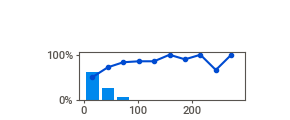
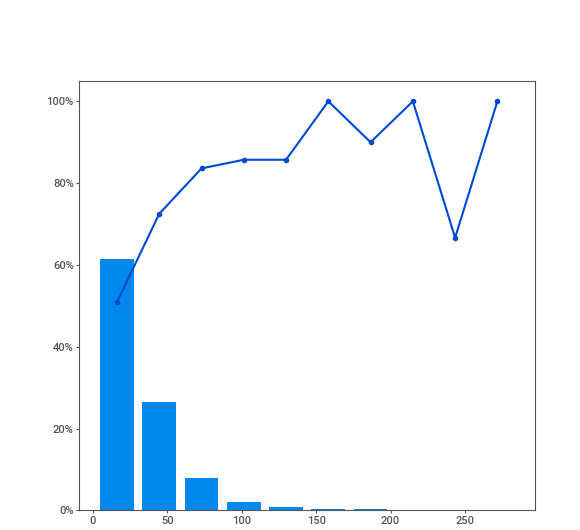
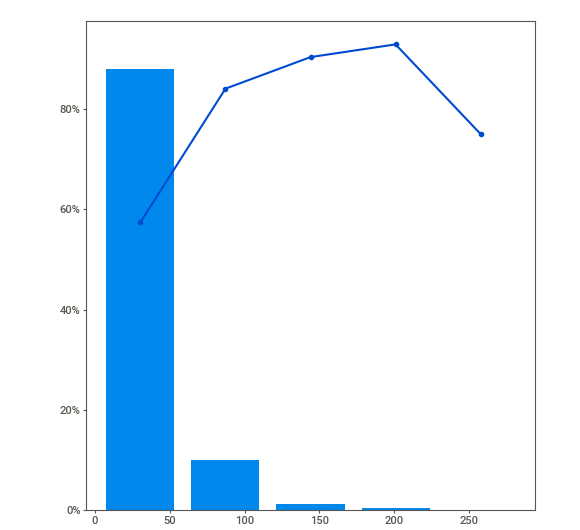
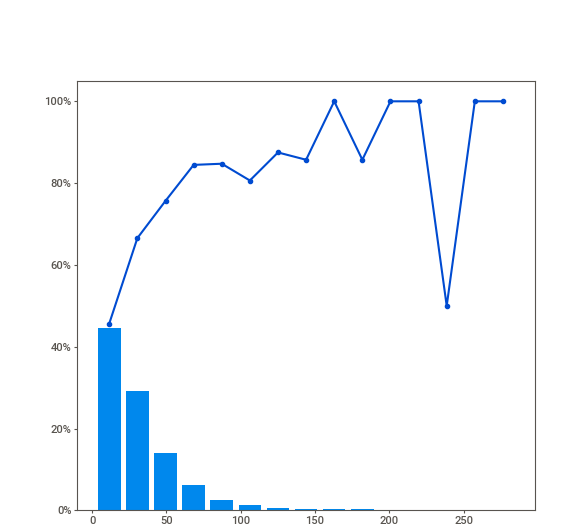
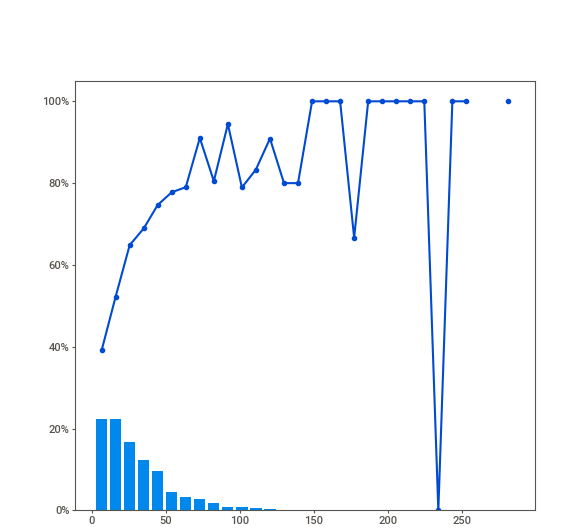
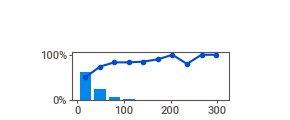
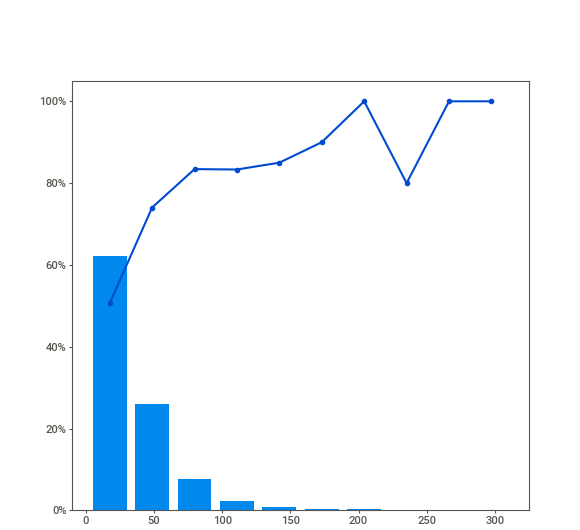
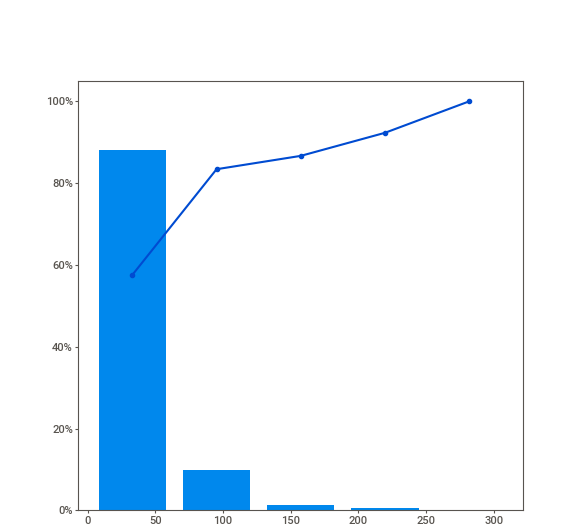
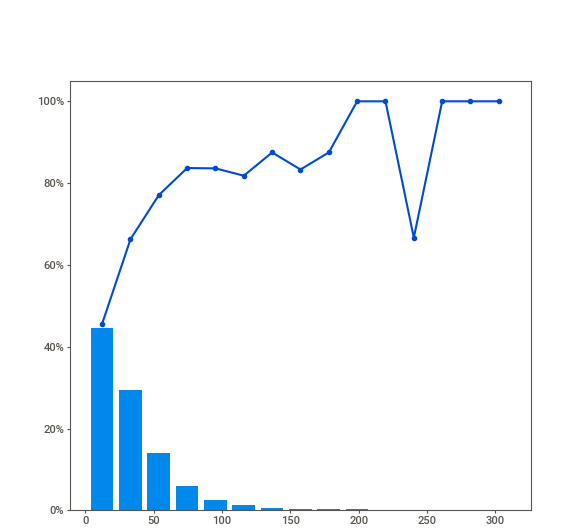
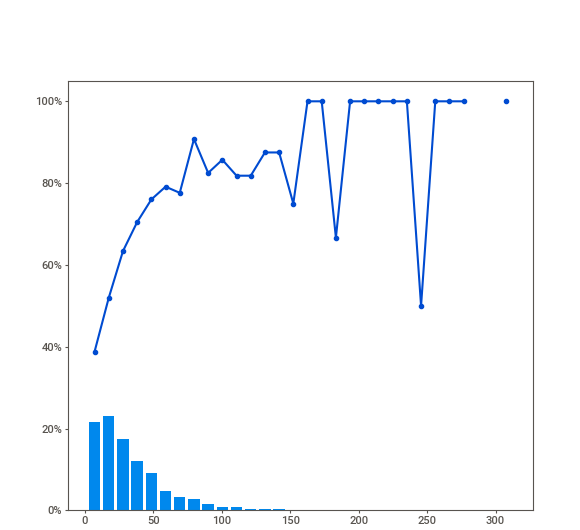
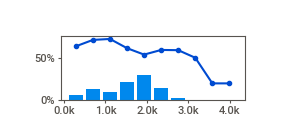
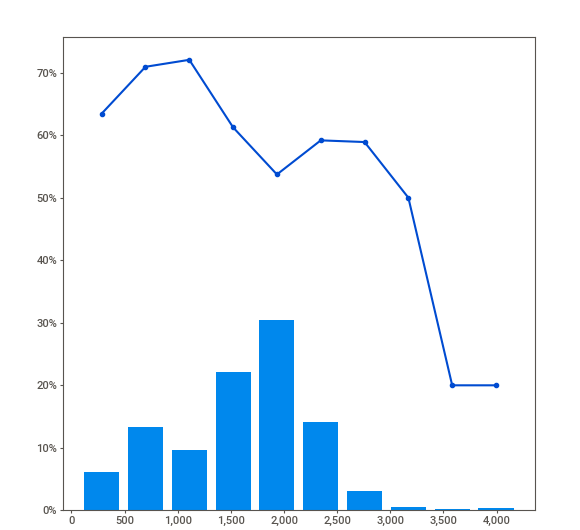
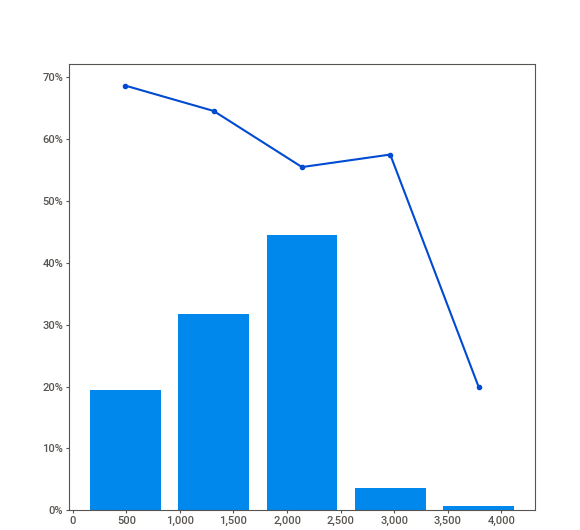
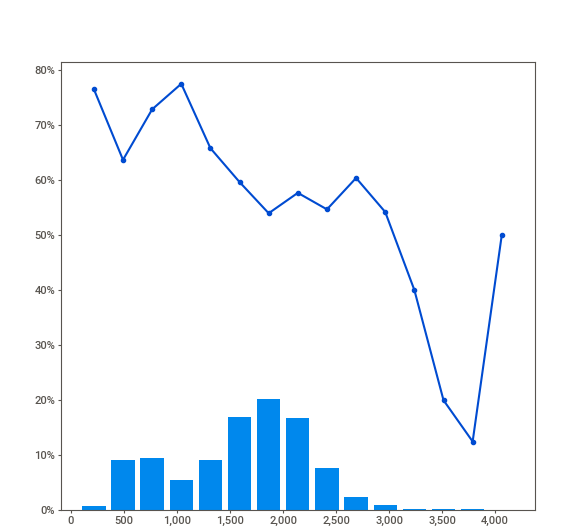
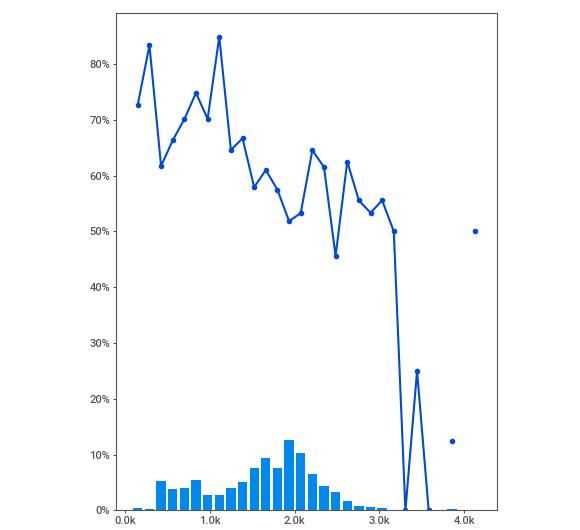
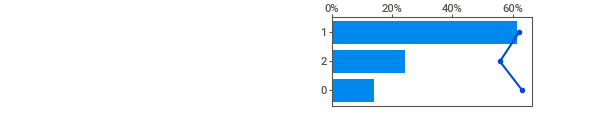
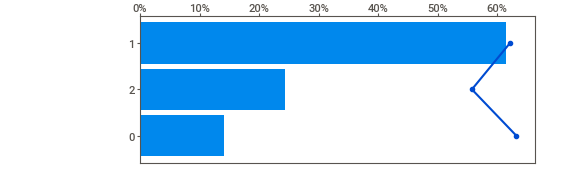
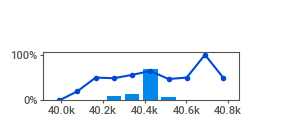
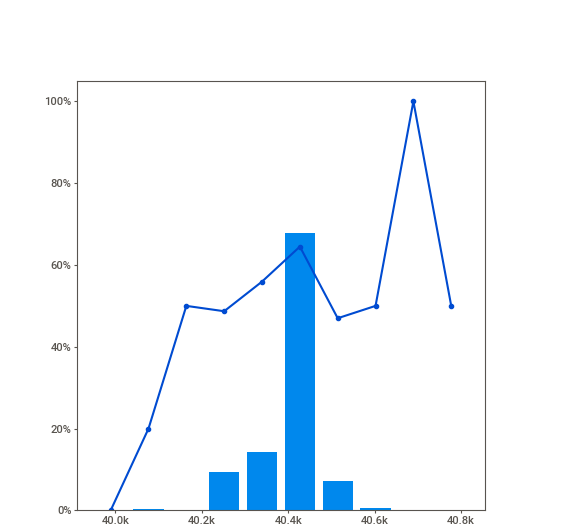
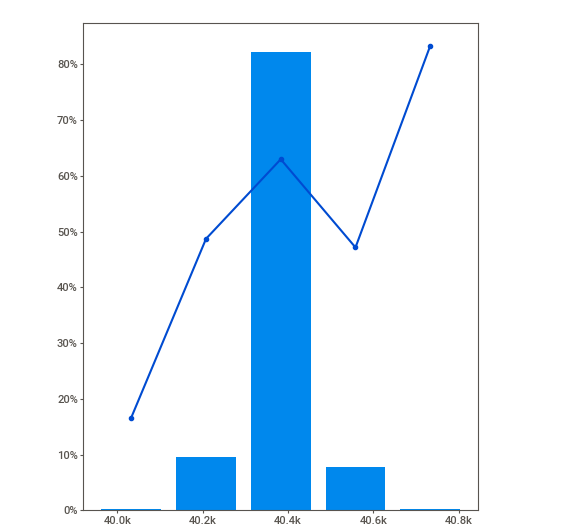
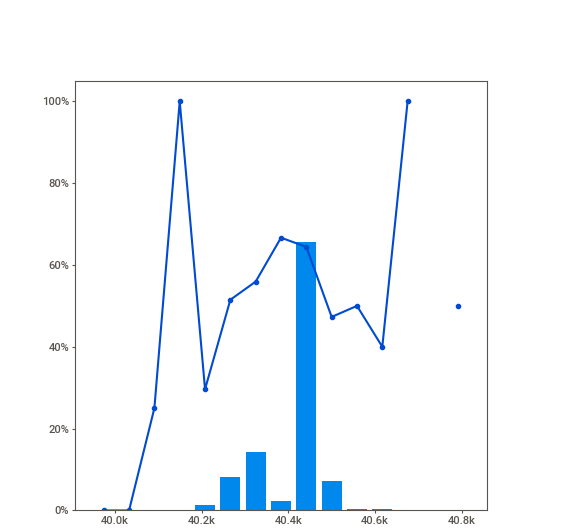
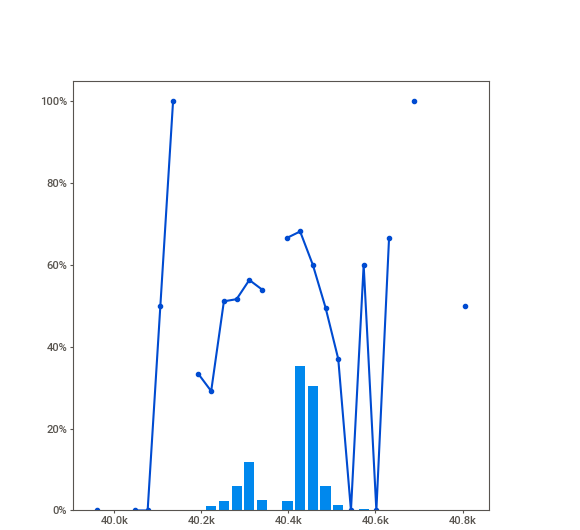
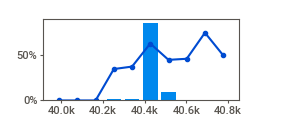
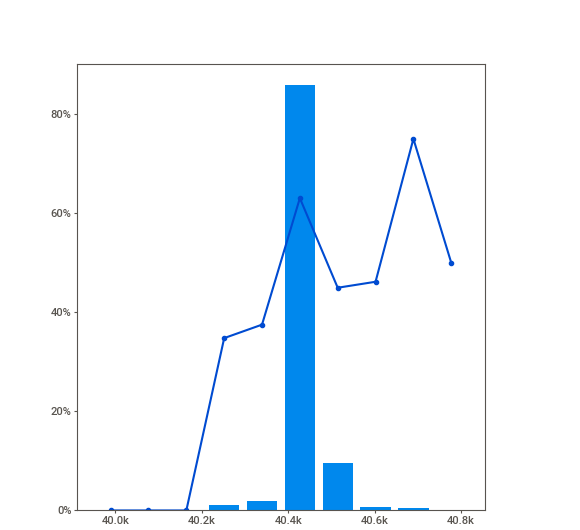
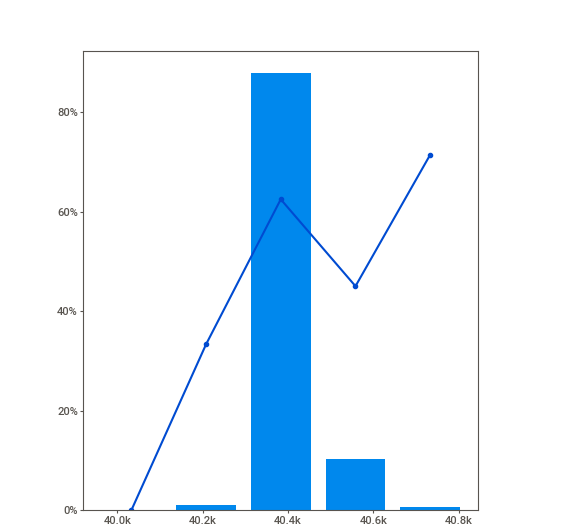
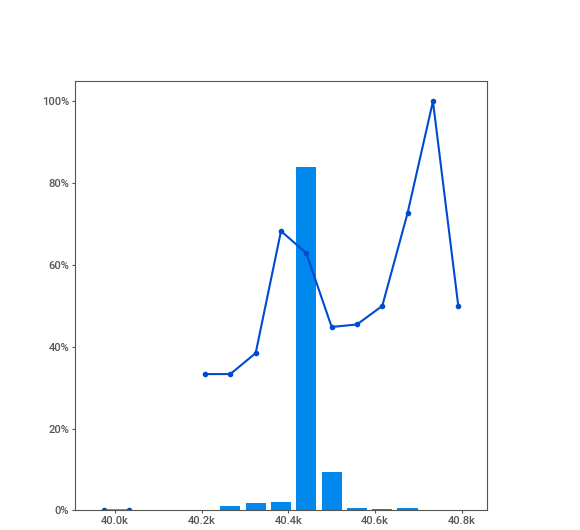
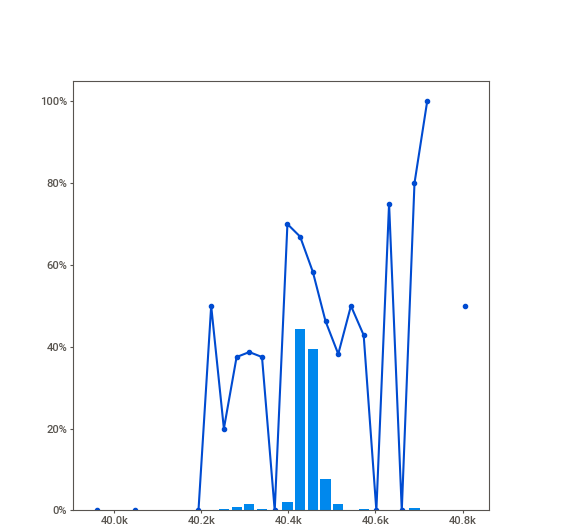
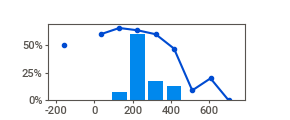
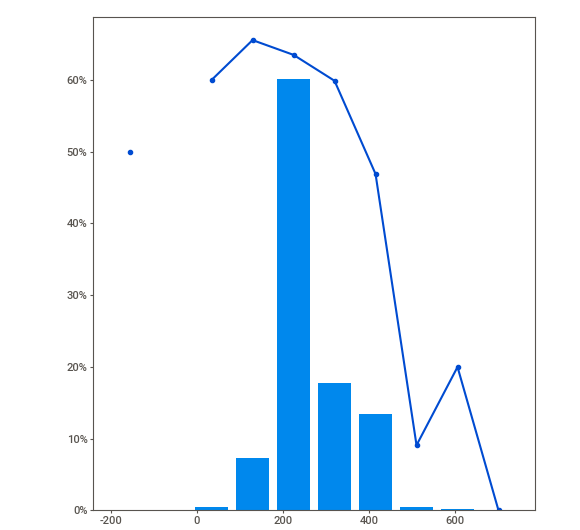
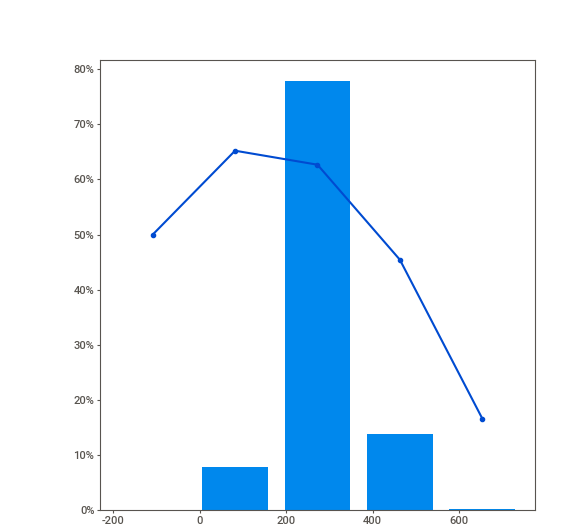
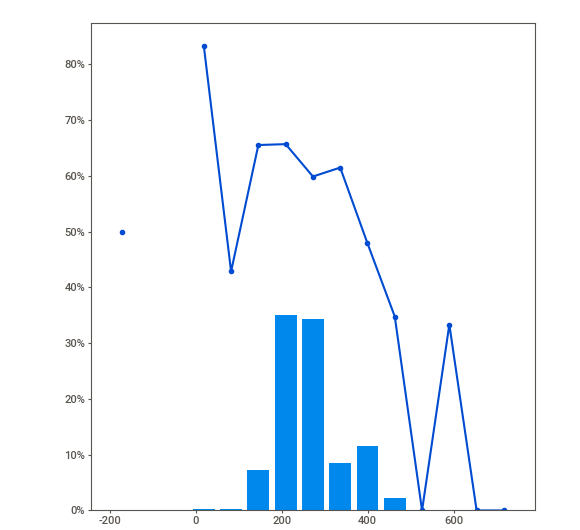
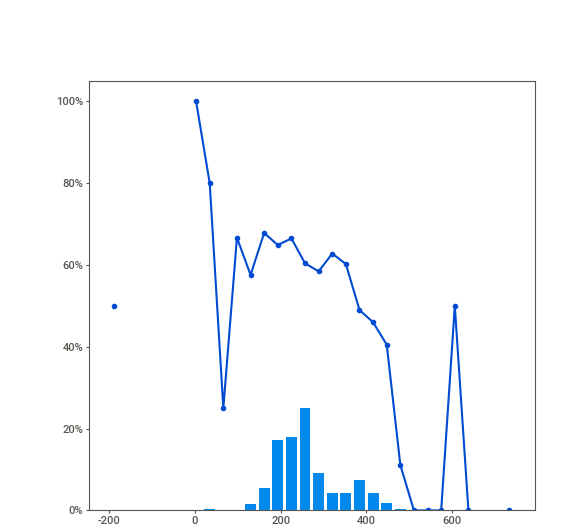
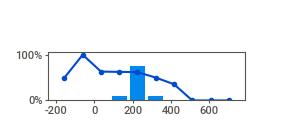
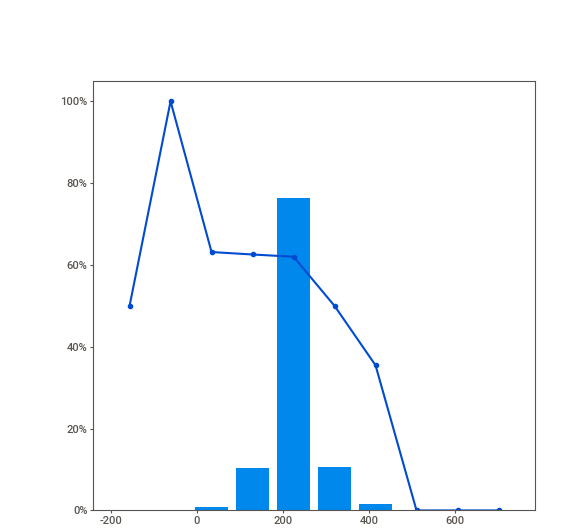
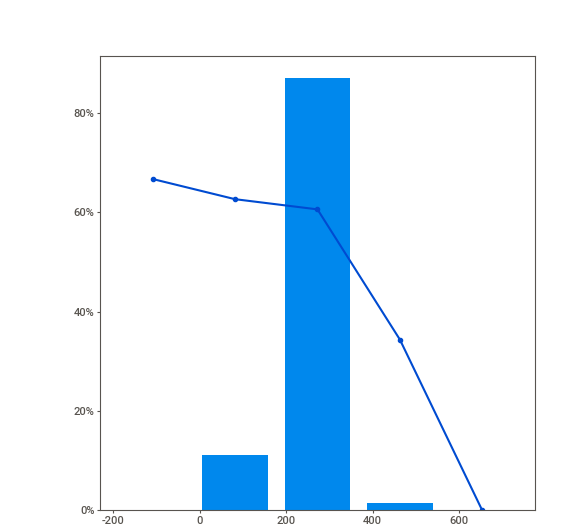
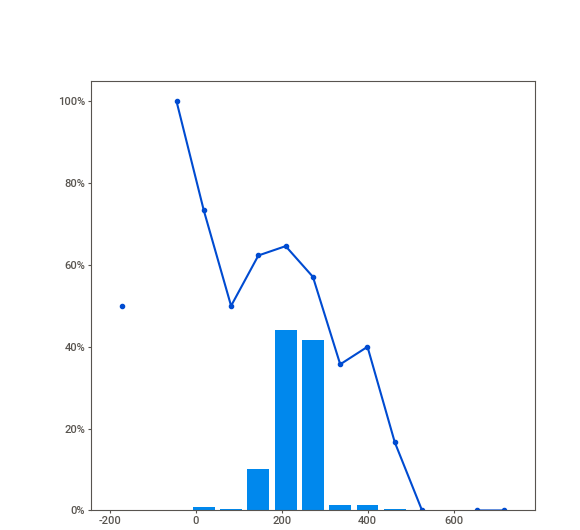
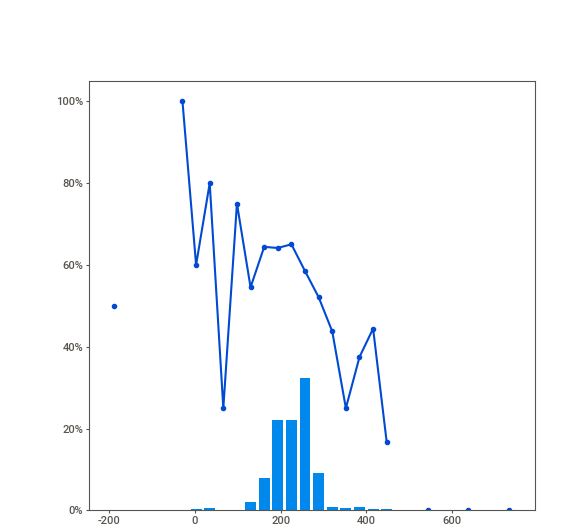
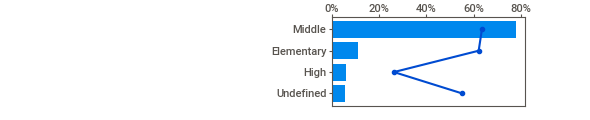
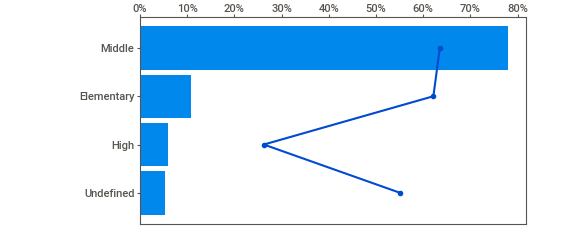
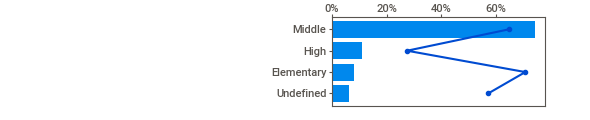
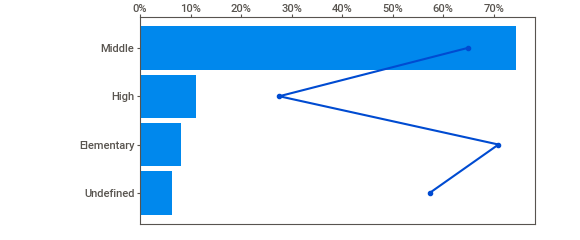
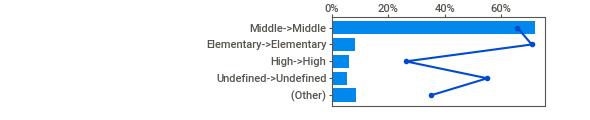
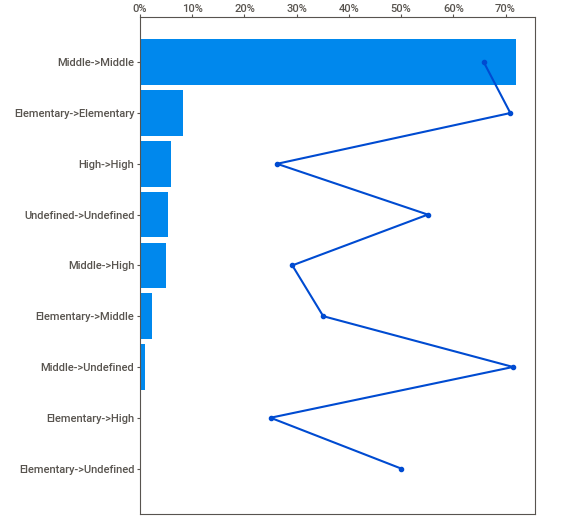
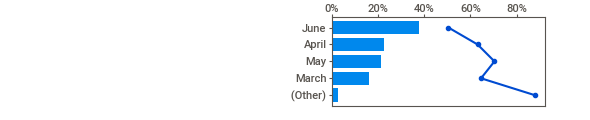
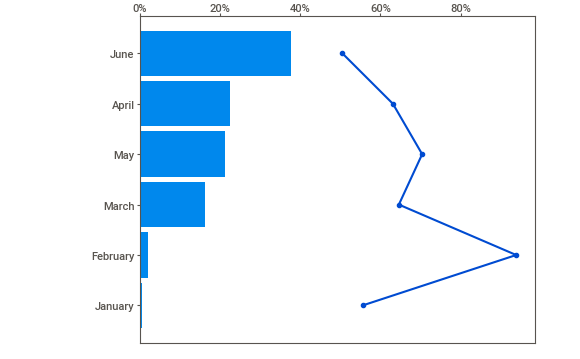
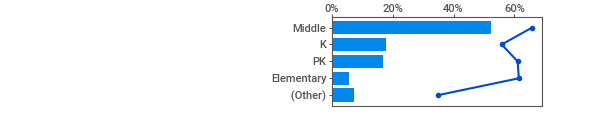
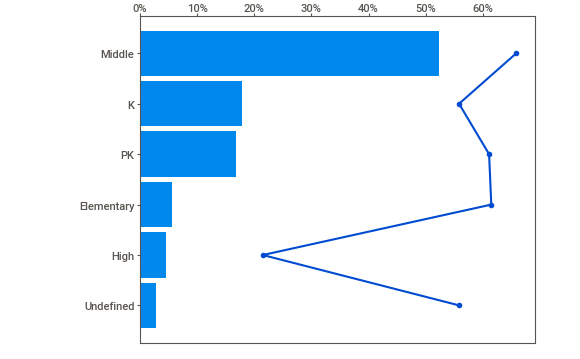
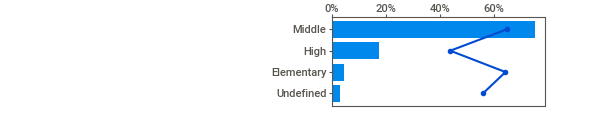
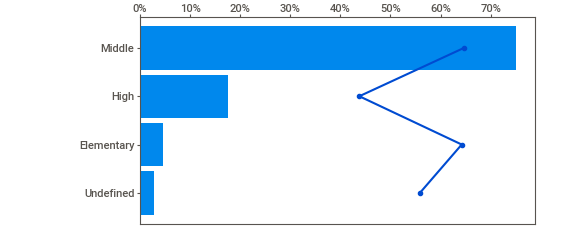
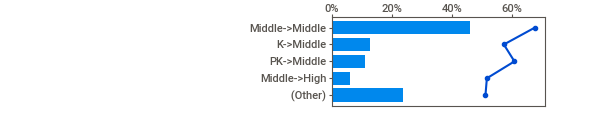
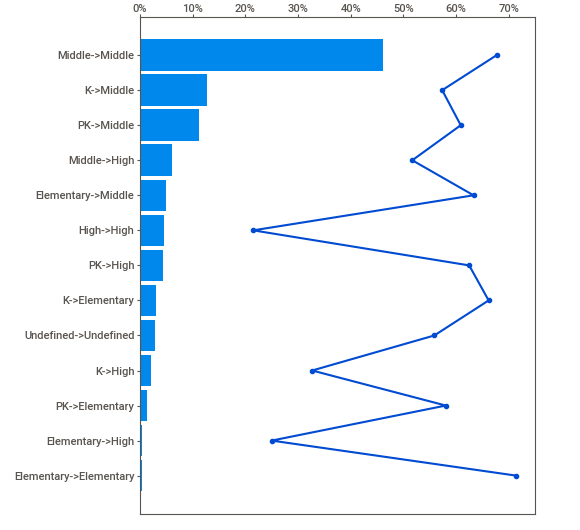
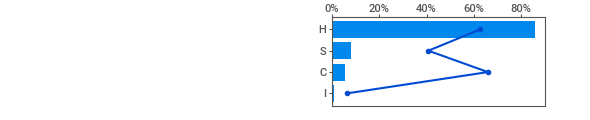
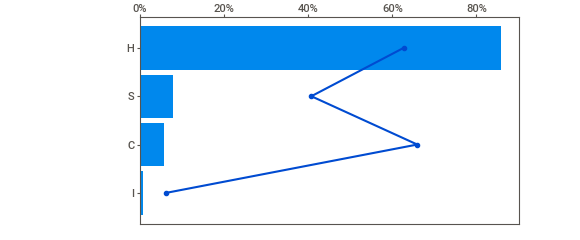
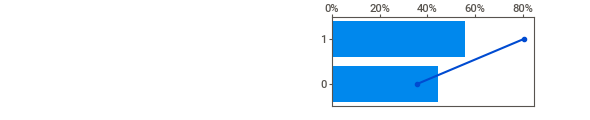
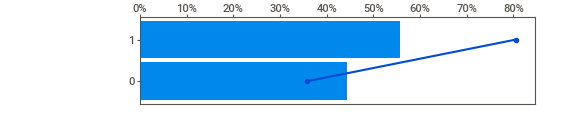
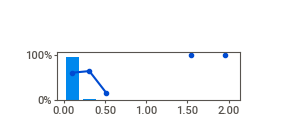
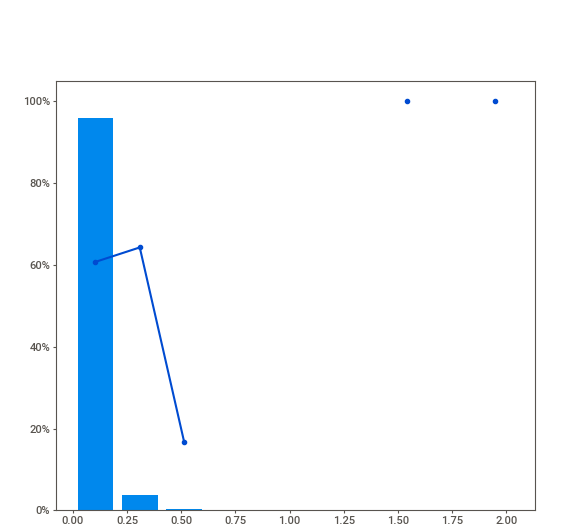
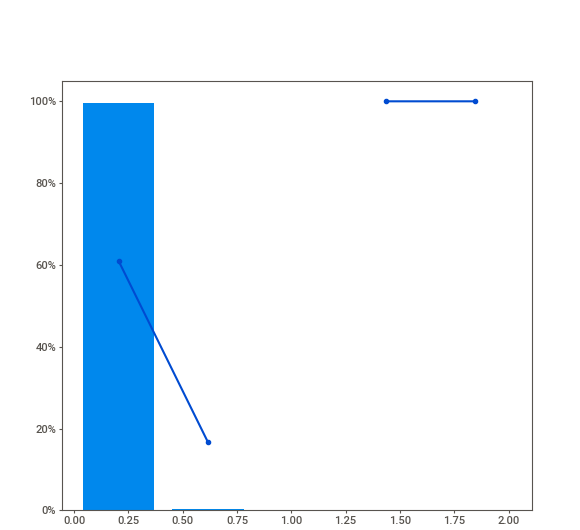
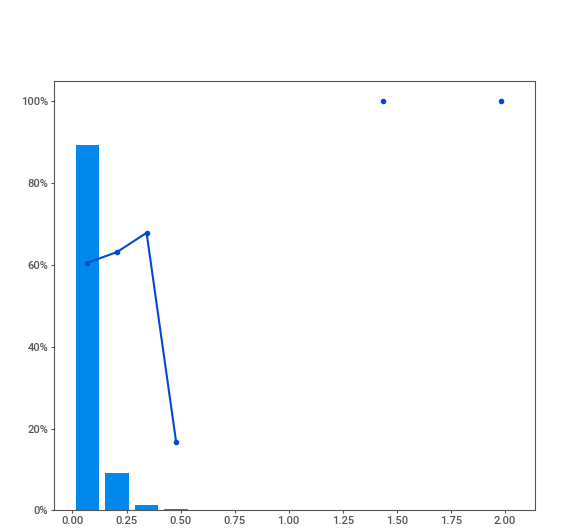
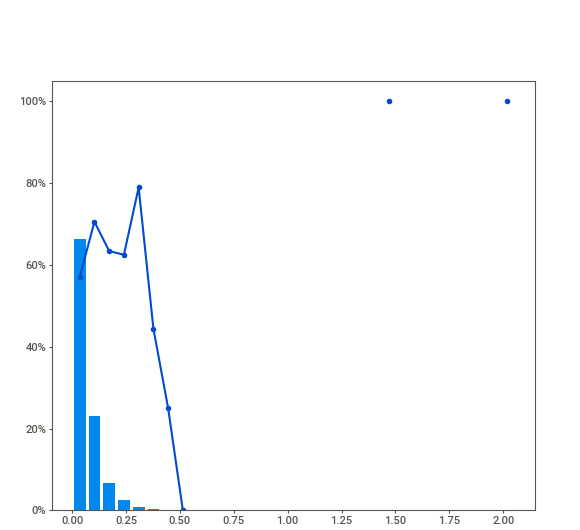
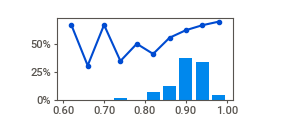
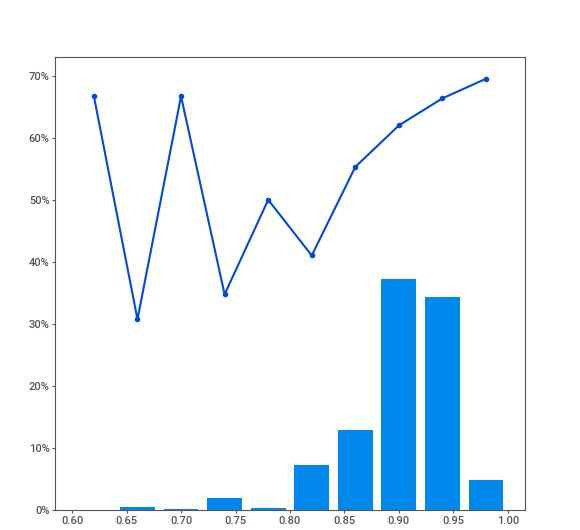
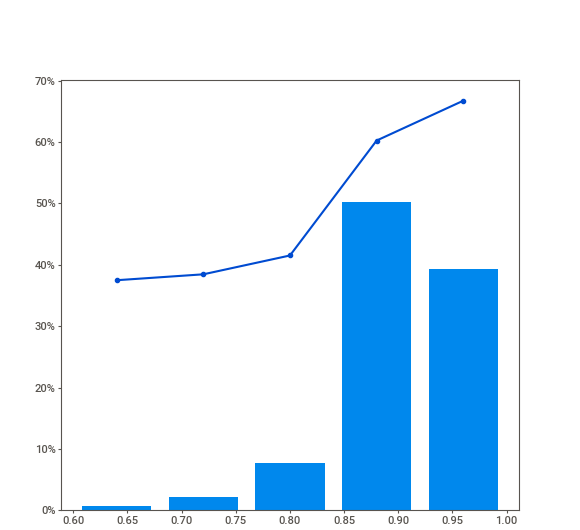
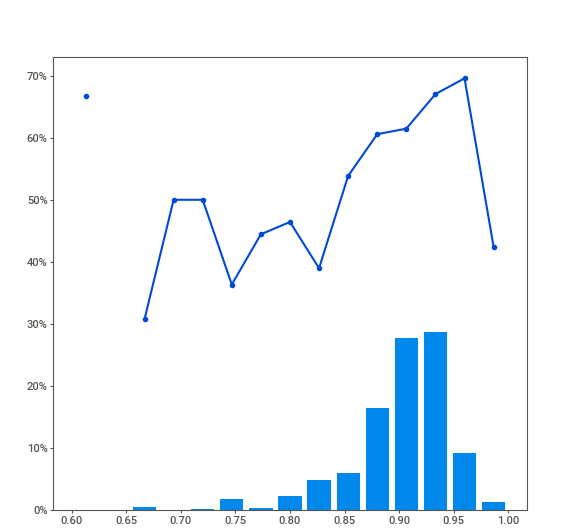
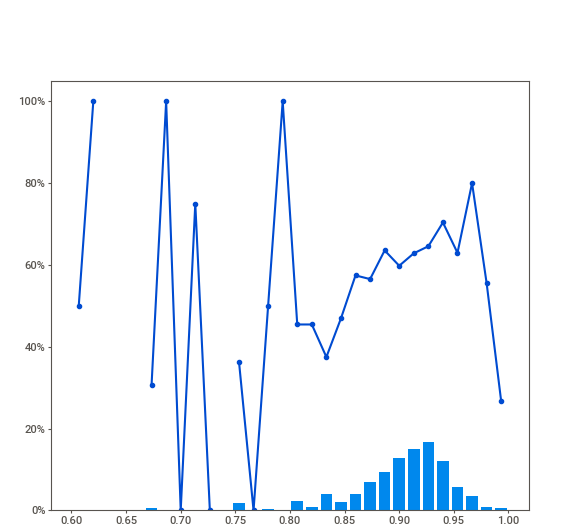
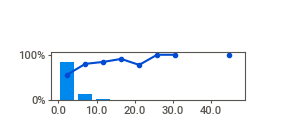
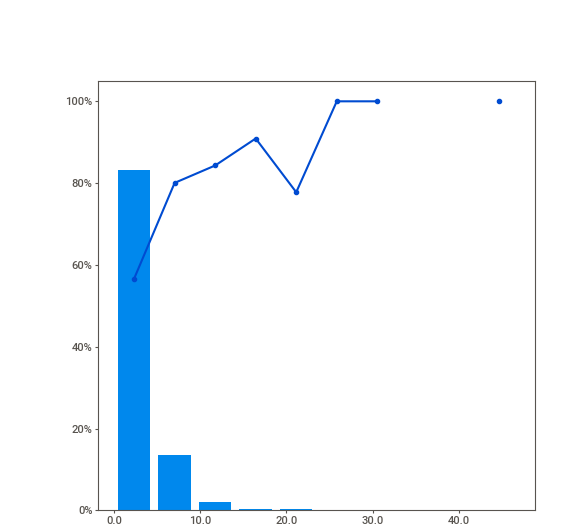
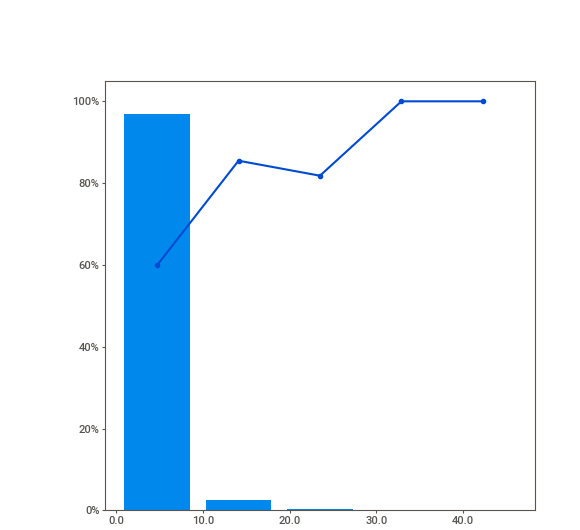
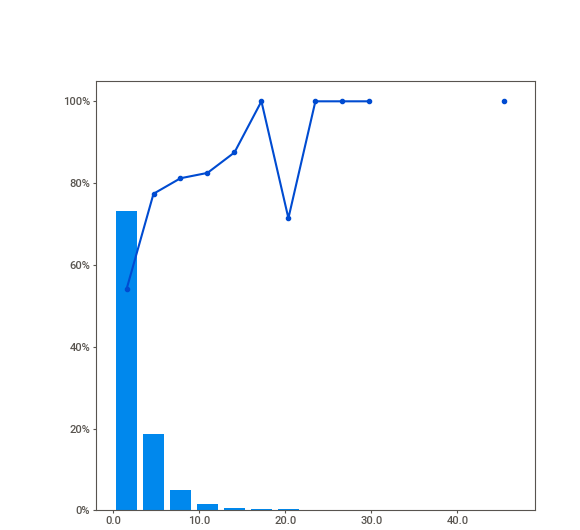
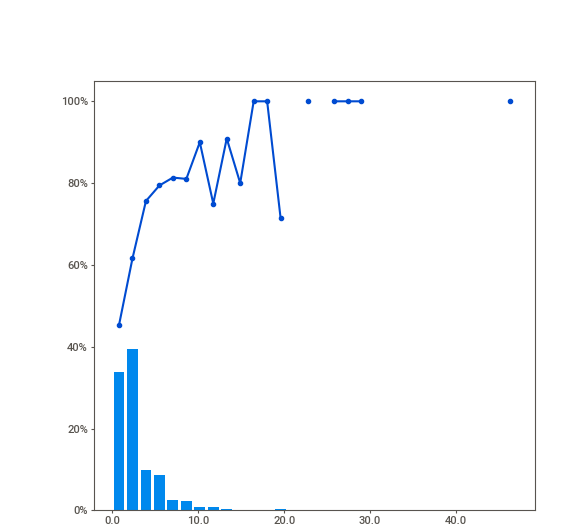
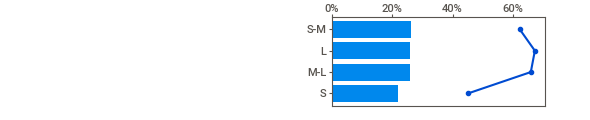
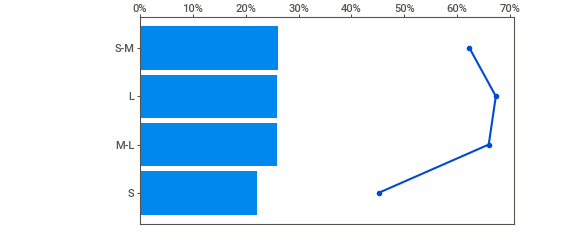
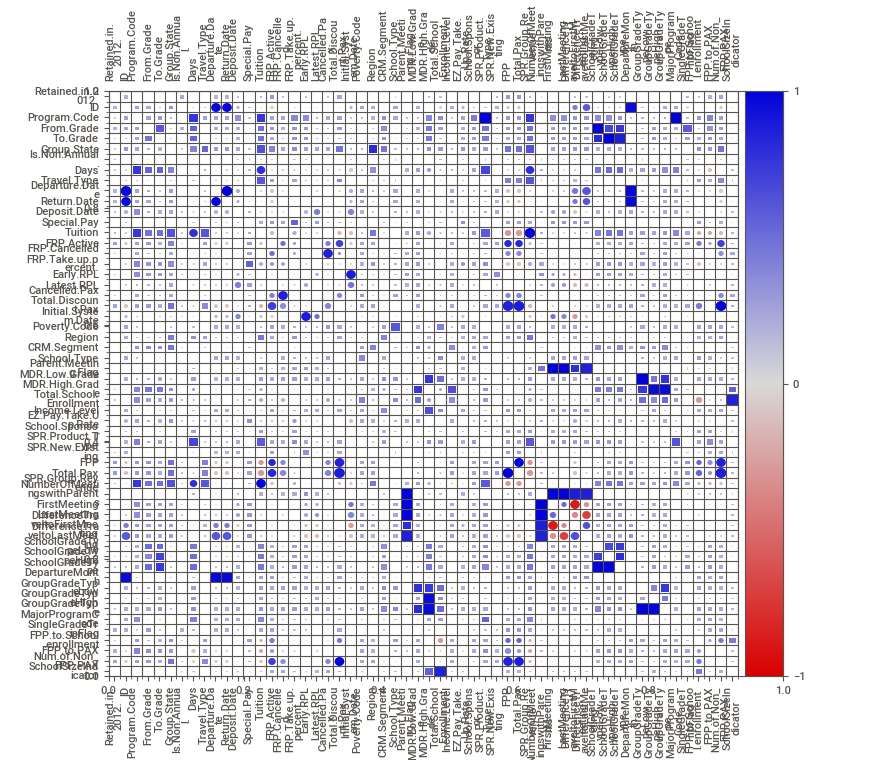
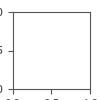

In [11]:
# Sweetviz compara la distribución de CADA variable entre los dos grupos:
#   → Retenidos (Retained = 1) vs No Retenidos (Retained = 0)
# Esto revela directamente qué variables discriminan mejor la retención,
# antes de entrenar ningún modelo.

reporte_sv = sv.analyze(
    df,
    target_feat='Retained.in.2012.'
)

reporte_sv.show_html("reporte_sweetviz_STC.html")
print("✅ Reporte guardado como 'reporte_sweetviz_STC.html'")

# Vista inline
reporte_sv.show_notebook(w="100%", h=500)

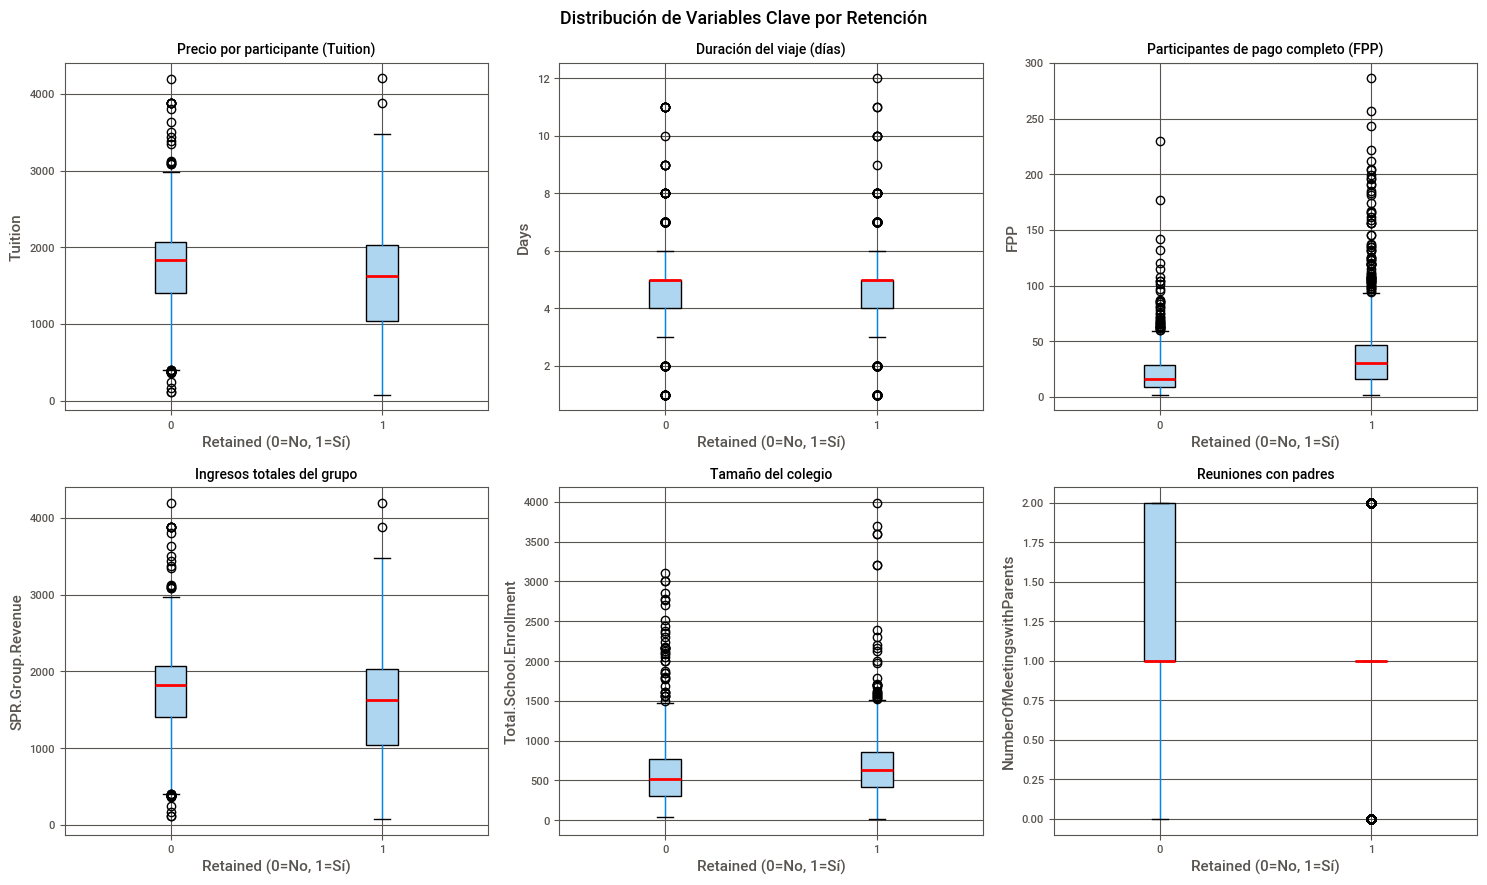

In [12]:
# Complementamos el EDA automático con visualizaciones específicas
# de las variables que el dominio del negocio sugiere como relevantes

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

vars_interes = [
    ('Tuition',                 'Precio por participante (Tuition)'),
    ('Days',                    'Duración del viaje (días)'),
    ('FPP',                     'Participantes de pago completo (FPP)'),
    ('SPR.Group.Revenue',       'Ingresos totales del grupo'),
    ('Total.School.Enrollment', 'Tamaño del colegio'),
    ('NumberOfMeetingswithParents', 'Reuniones con padres'),
]

for ax, (col, titulo) in zip(axes, vars_interes):
    df.boxplot(column=col, by='Retained.in.2012.', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#aed6f1'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Retained (0=No, 1=Sí)')
    ax.set_ylabel(col)

plt.suptitle('Distribución de Variables Clave por Retención', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Top 15 variables más correlacionadas con la retención ===
SingleGradeTripFlag               0.455872
Is.Non.Annual.                   -0.390633
FPP                               0.261127
Total.Pax                         0.260492
FRP.Active                        0.250478
Total.Discount.Pax                0.216218
Num.of.Non_FPP.PAX                0.216218
To.Grade                         -0.200470
ID                               -0.148490
FPP.to.PAX                        0.145107
Return.Date                      -0.135482
MDR.High.Grade                   -0.135009
Departure.Date                   -0.134576
DifferenceTraveltoFirstMeeting   -0.130223
School.Sponsor                    0.120717


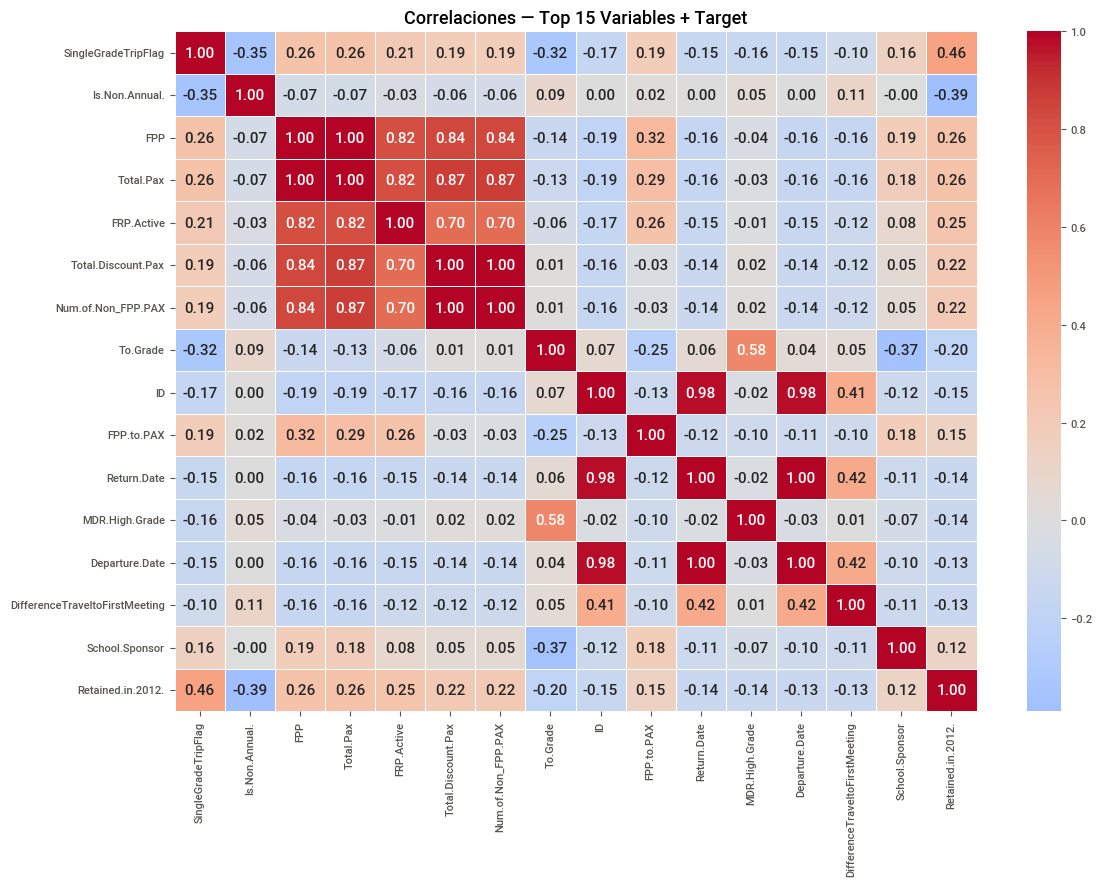

In [13]:
# Correlación entre variables numéricas y la variable objetivo
# Nos muestra qué tan linealmente relacionadas están con la retención

numericas = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numericas].corr()

# Correlación de cada variable con el target
corr_target = corr_matrix['Retained.in.2012.'].drop('Retained.in.2012.')\
                .sort_values(key=abs, ascending=False)

print("=== Top 15 variables más correlacionadas con la retención ===")
print(corr_target.head(15).to_string())

# Heatmap de las 15 variables más correlacionadas entre sí
top_vars = corr_target.head(15).index.tolist() + ['Retained.in.2012.']
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_vars].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlaciones — Top 15 Variables + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Data preparation

In [14]:
# =============================================================================
# FASE 3 — DATA PREPARATION
# =============================================================================
# Eliminamos columnas que no aportan información predictiva:
#   • ID: identificador sin valor predictivo
#   • Fechas brutas: ya existen versiones procesadas como diferencias en días
#     (DifferenceTraveltoFirstMeeting, etc.), que son más informativas

drop_cols = [
    'ID',
    'Departure.Date', 'Return.Date', 'Deposit.Date',
    'Early.RPL', 'Latest.RPL', 'Initial.System.Date',
    'FirstMeeting', 'LastMeeting'
]
df_clean = df.drop(columns=drop_cols, errors='ignore').copy()

print(f"Columnas antes: {df.shape[1]}  →  después: {df_clean.shape[1]}")
print(f"Columnas eliminadas: {drop_cols}")

Columnas antes: 56  →  después: 47
Columnas eliminadas: ['ID', 'Departure.Date', 'Return.Date', 'Deposit.Date', 'Early.RPL', 'Latest.RPL', 'Initial.System.Date', 'FirstMeeting', 'LastMeeting']


In [15]:
TARGET = 'Retained.in.2012.'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nDistribución del target:\n{y.value_counts()}")

Features (X): (2389, 46)
Target  (y): (2389,)

Distribución del target:
Retained.in.2012.
1    1451
0     938
Name: count, dtype: int64


In [16]:
# Los modelos basados en árboles (RF, XGBoost, etc.) trabajan con números.
# Usamos Label Encoding: convierte cada categoría en un entero.
# Es apropiado para árboles porque no asumen orden lineal entre los números;
# en cada split el árbol evalúa umbrales de forma discreta.

cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Variables categóricas a codificar ({len(cat_cols)}):\n{cat_cols}")

le = LabelEncoder()
X_enc = X.copy()

for col in cat_cols:
    X_enc[col] = X_enc[col].astype(str)           # Tratar NaN como string "nan"
    X_enc[col] = le.fit_transform(X_enc[col])      # Asignar entero a cada categoría

print("\n✅ Encoding completado")

Variables categóricas a codificar (20):
['Program.Code', 'Group.State', 'Travel.Type', 'Special.Pay', 'Poverty.Code', 'Region', 'School.Type', 'MDR.Low.Grade', 'Income.Level', 'SPR.Product.Type', 'SPR.New.Existing', 'SchoolGradeTypeLow', 'SchoolGradeTypeHigh', 'SchoolGradeType', 'DepartureMonth', 'GroupGradeTypeLow', 'GroupGradeTypeHigh', 'GroupGradeType', 'MajorProgramCode', 'SchoolSizeIndicator']

✅ Encoding completado


In [17]:
# Imputamos valores nulos con la mediana de cada columna.
# La mediana es más robusta que la media ante valores extremos,
# que existen en variables como SPR.Group.Revenue o Total.School.Enrollment.

X_enc = X_enc.fillna(X_enc.median(numeric_only=True))

print(f"Nulos antes de imputar : {X.isnull().sum().sum()}")
print(f"Nulos después de imputar: {X_enc.isnull().sum().sum()}")
print(f"\nShape final de X: {X_enc.shape}")

Nulos antes de imputar : 3944
Nulos después de imputar: 0

Shape final de X: (2389, 46)


In [19]:
# 80% entrenamiento, 20% prueba
# stratify=y garantiza que la proporción 0/1 sea idéntica en ambas particiones,
# lo cual es importante para datasets con desbalance moderado como este.

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape}  |  Retención: {y_train.mean():.2%}")
print(f"Test  : {X_test.shape}  |  Retención: {y_test.mean():.2%}")

Train : (1911, 46)  |  Retención: 60.75%
Test  : (478, 46)  |  Retención: 60.67%


# Modelling

In [21]:
# =============================================================================
# FASE 4 — MODELING
# Definimos funciones de evaluación para no repetir código en cada modelo
# =============================================================================

results_summary = {}   # Acumulador de métricas para la comparación final

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """
    Entrena el modelo y reporta:
      - Accuracy en test
      - ROC-AUC en test   (métrica principal)
      - ROC-AUC en CV 5-fold sobre train  (detecta overfitting)
      - Classification report completo
    Guarda los resultados en results_summary para el cuadro comparativo final.
    """
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]   # Prob. de clase positiva

    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)
    cv_auc = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='roc_auc').mean()

    results_summary[nombre] = {
        'Accuracy':       round(acc,    4),
        'ROC-AUC (test)': round(auc,    4),
        'CV AUC (5-fold)':round(cv_auc, 4)
    }

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  ROC-AUC test   : {auc:.4f}")
    print(f"  CV AUC 5-fold  : {cv_auc:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['No Retenido','Retenido'])}")

    return modelo, y_pred, y_prob


def plot_confusion_roc(nombre, y_te, y_pred, y_prob):
    """Matriz de confusión + curva ROC lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Retenido', 'Retenido']).plot(
        ax=axes[0], colorbar=False, cmap='Blues'
    )
    axes[0].set_title(f'{nombre}\nMatriz de Confusión')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    axes[1].set_xlabel('FPR (Falsos Positivos)')
    axes[1].set_ylabel('TPR (Verdaderos Positivos)')
    axes[1].set_title(f'{nombre}\nCurva ROC')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

print("✅ Funciones de evaluación definidas")

✅ Funciones de evaluación definidas



  Árbol de Decisión (Baseline)
  Accuracy       : 0.7322
  ROC-AUC test   : 0.7120
  CV AUC 5-fold  : 0.6773

              precision    recall  f1-score   support

 No Retenido       0.67      0.62      0.64       188
    Retenido       0.76      0.81      0.79       290

    accuracy                           0.73       478
   macro avg       0.72      0.71      0.71       478
weighted avg       0.73      0.73      0.73       478



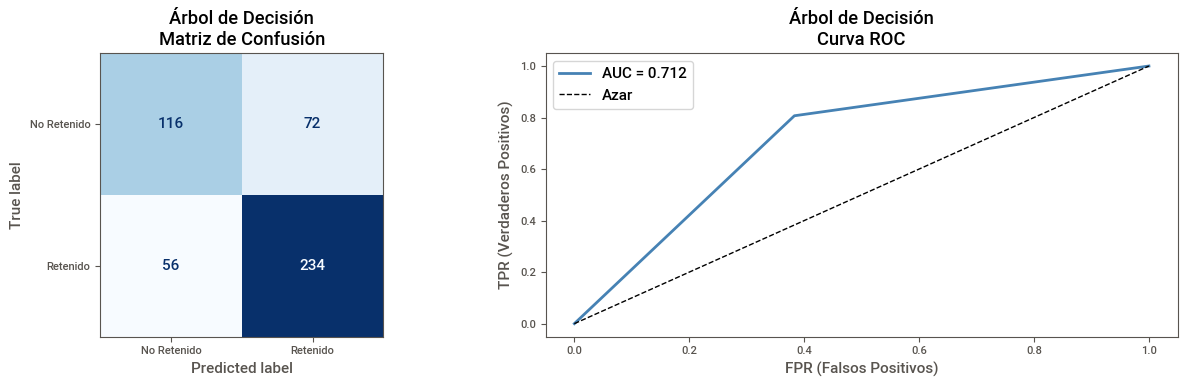

In [22]:
# ─── BASELINE ─────────────────────────────────────────────────────────────────
# Un árbol sin restricciones y sin ensamble.
# Sirve como punto de comparación: cualquier ensamble debe superar esto.
# Problema esperado: alta varianza → overfitting → bajo desempeño en test.

dt = DecisionTreeClassifier(random_state=42)

dt, y_pred_dt, y_prob_dt = evaluar_modelo(
    'Árbol de Decisión (Baseline)',
    dt, X_train, y_train, X_test, y_test
)
plot_confusion_roc('Árbol de Decisión', y_test, y_pred_dt, y_prob_dt)


  BaggingClassifier
  Accuracy       : 0.7950
  ROC-AUC test   : 0.8558
  CV AUC 5-fold  : 0.8570

              precision    recall  f1-score   support

 No Retenido       0.73      0.75      0.74       188
    Retenido       0.84      0.82      0.83       290

    accuracy                           0.79       478
   macro avg       0.79      0.79      0.79       478
weighted avg       0.80      0.79      0.80       478



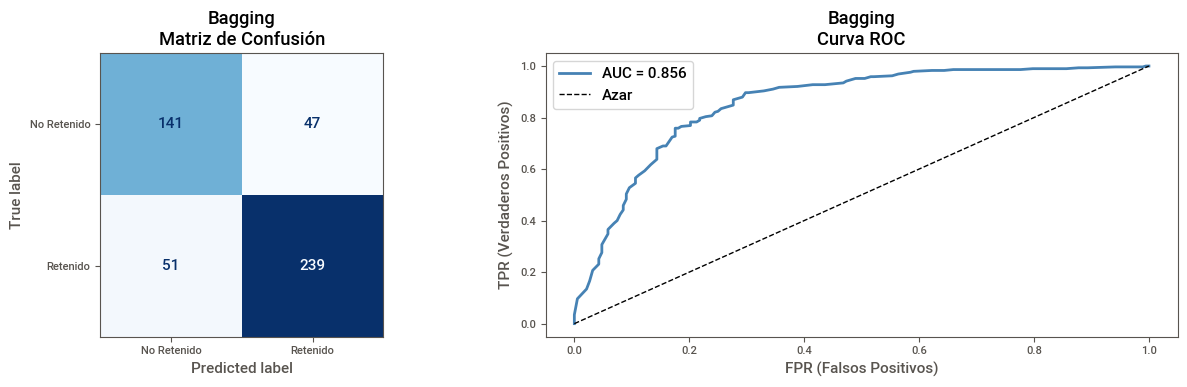

In [23]:
# ─── BAGGING ──────────────────────────────────────────────────────────────────
# Entrena N árboles en paralelo, cada uno sobre un subconjunto aleatorio
# de filas (bootstrap) y columnas. La predicción final es el voto mayoritario.
# Efecto principal: REDUCE LA VARIANZA del modelo base.

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,   # Número de árboles en el ensamble
    max_samples=0.8,    # Cada árbol entrena con el 80% de las filas
    max_features=0.8,   # Cada árbol usa el 80% de las columnas
    bootstrap=True,     # Muestreo CON reemplazo (bootstrap clásico)
    random_state=42,
    n_jobs=-1           # Paraleliza en todos los núcleos disponibles
)

bag, y_pred_bag, y_prob_bag = evaluar_modelo(
    'BaggingClassifier',
    bag, X_train, y_train, X_test, y_test
)
plot_confusion_roc('Bagging', y_test, y_pred_bag, y_prob_bag)


  Random Forest
  Accuracy       : 0.8201
  ROC-AUC test   : 0.8629
  CV AUC 5-fold  : 0.8641

              precision    recall  f1-score   support

 No Retenido       0.78      0.76      0.77       188
    Retenido       0.84      0.86      0.85       290

    accuracy                           0.82       478
   macro avg       0.81      0.81      0.81       478
weighted avg       0.82      0.82      0.82       478



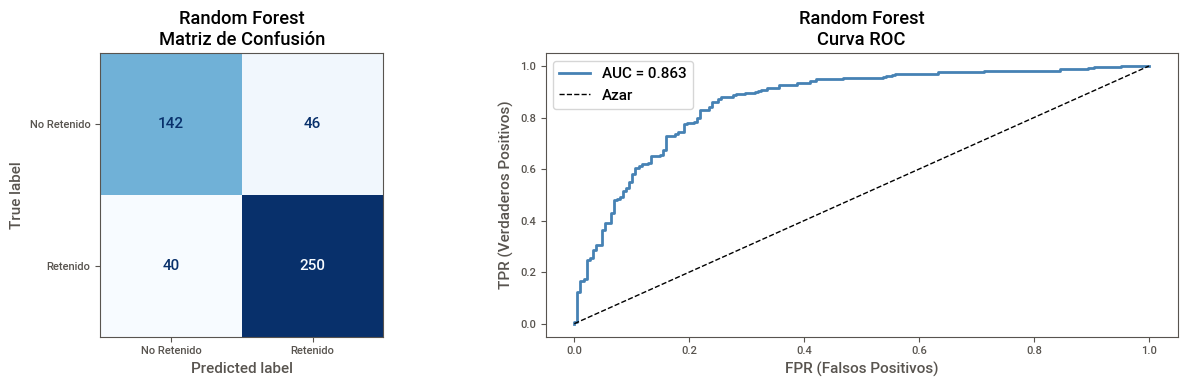

In [24]:
# Random Forest es Bagging con una restricción adicional:
# en cada SPLIT del árbol solo se evalúa un subconjunto aleatorio de features.
# Esto desorrela los árboles entre sí → mayor reducción de varianza que Bagging puro.

rf = RandomForestClassifier(
    n_estimators=200,       # Más árboles = predicciones más estables
    max_depth=10,           # Limita profundidad para evitar overfitting
    max_features='sqrt',    # En cada split se prueban √(n_features) variables
    min_samples_leaf=5,     # Hoja válida = mínimo 5 muestras
    random_state=42,
    n_jobs=-1
)

rf, y_pred_rf, y_prob_rf = evaluar_modelo(
    'Random Forest',
    rf, X_train, y_train, X_test, y_test
)
plot_confusion_roc('Random Forest', y_test, y_pred_rf, y_prob_rf)

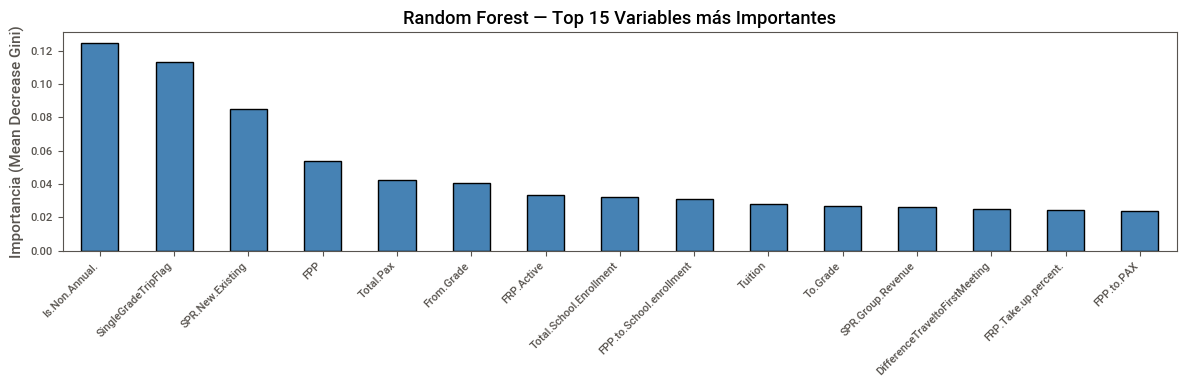

Top 10 variables:
Is.Non.Annual.              0.124773
SingleGradeTripFlag         0.113151
SPR.New.Existing            0.084755
FPP                         0.054013
Total.Pax                   0.042385
From.Grade                  0.040660
FRP.Active                  0.033414
Total.School.Enrollment     0.032512
FPP.to.School.enrollment    0.030864
Tuition                     0.027981


In [25]:
# El RF calcula la importancia de cada variable como la reducción acumulada
# del índice Gini a lo largo de todos los árboles (Mean Decrease Impurity).
# Las variables más importantes en el negocio de retención de STC.

feat_imp_rf = pd.Series(
    rf.feature_importances_,
    index=X_enc.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
feat_imp_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest — Top 15 Variables más Importantes')
plt.ylabel('Importancia (Mean Decrease Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 variables:")
print(feat_imp_rf.head(10).to_string())

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
   Mejor CV AUC: 0.8669

  Random Forest (Optimizado)
  Accuracy       : 0.8201
  ROC-AUC test   : 0.8595
  CV AUC 5-fold  : 0.8669

              precision    recall  f1-score   support

 No Retenido       0.80      0.73      0.76       188
    Retenido       0.83      0.88      0.86       290

    accuracy                           0.82       478
   macro avg       0.81      0.80      0.81       478
weighted avg       0.82      0.82      0.82       478



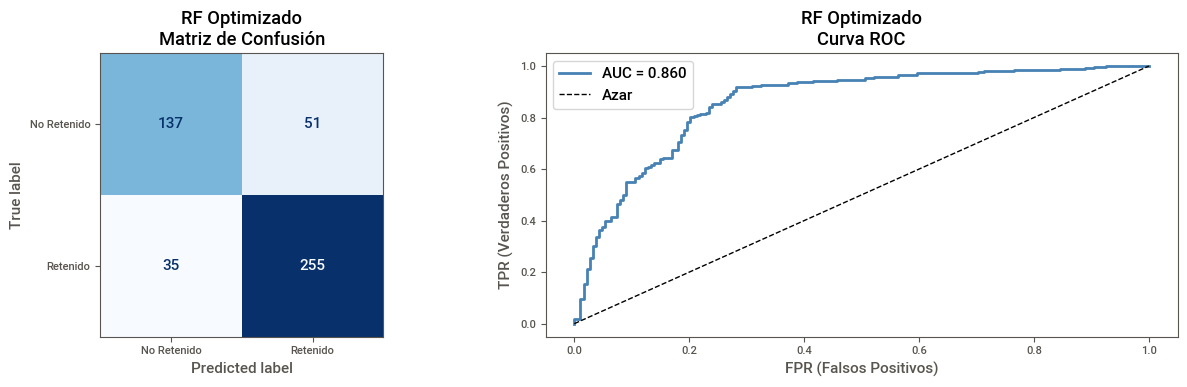

In [26]:
# GridSearchCV prueba TODAS las combinaciones del grid definido
# y elige la que maximiza el ROC-AUC en validación cruzada de 5 folds.
# Es exhaustivo: útil cuando el espacio de búsqueda es manejable.

param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [5, 10, None],    # None = sin límite de profundidad
    'min_samples_leaf': [3, 5, 10],
    'max_features':     ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"   Mejor CV AUC: {grid_rf.best_score_:.4f}")

rf_opt, y_pred_rfopt, y_prob_rfopt = evaluar_modelo(
    'Random Forest (Optimizado)',
    grid_rf.best_estimator_, X_train, y_train, X_test, y_test
)
plot_confusion_roc('RF Optimizado', y_test, y_pred_rfopt, y_prob_rfopt)


  AdaBoost
  Accuracy       : 0.8054
  ROC-AUC test   : 0.8527
  CV AUC 5-fold  : 0.8627

              precision    recall  f1-score   support

 No Retenido       0.78      0.70      0.74       188
    Retenido       0.82      0.88      0.85       290

    accuracy                           0.81       478
   macro avg       0.80      0.79      0.79       478
weighted avg       0.80      0.81      0.80       478



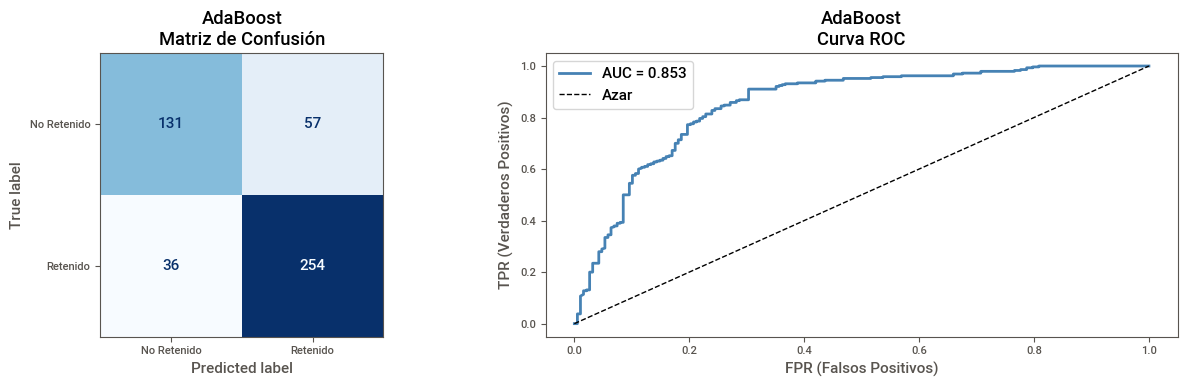

In [27]:
# ─── BOOSTING ─────────────────────────────────────────────────────────────────
# A diferencia del Bagging (paralelo), el Boosting entrena los modelos
# de forma SECUENCIAL: cada árbol corrige los errores del anterior.
# Efecto principal: REDUCE EL SESGO del modelo.

# AdaBoost: después de cada árbol, AUMENTA el peso de las muestras
# mal clasificadas para que el siguiente árbol las priorice.
# Usa stumps (árboles de profundidad 1) como estimadores débiles.

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Stump = estimador débil
    n_estimators=200,    # Número de estimadores débiles en secuencia
    learning_rate=0.5,   # Peso de cada árbol; bajo → necesita más estimadores
    random_state=42
)

ada, y_pred_ada, y_prob_ada = evaluar_modelo(
    'AdaBoost',
    ada, X_train, y_train, X_test, y_test
)
plot_confusion_roc('AdaBoost', y_test, y_pred_ada, y_prob_ada)


  Gradient Boosting (GBM)
  Accuracy       : 0.7992
  ROC-AUC test   : 0.8520
  CV AUC 5-fold  : 0.8638

              precision    recall  f1-score   support

 No Retenido       0.76      0.71      0.74       188
    Retenido       0.82      0.86      0.84       290

    accuracy                           0.80       478
   macro avg       0.79      0.78      0.79       478
weighted avg       0.80      0.80      0.80       478



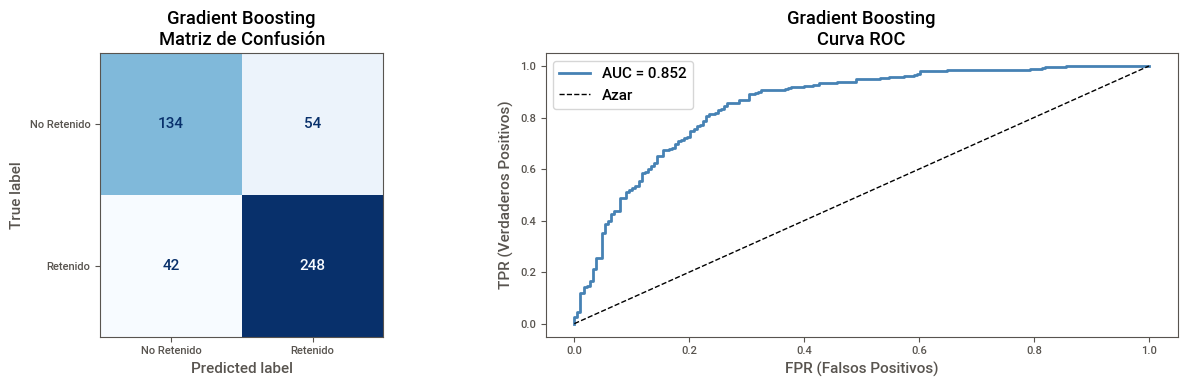

In [28]:
# GBM: en lugar de reponderar muestras, cada árbol ajusta los RESIDUOS
# del árbol anterior, siguiendo el gradiente de la función de pérdida.
# subsample < 1 lo hace "estocástico" → más robusto ante overfitting.

gbm = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,   # Tasa de aprendizaje: cuánto aporta cada árbol
    max_depth=4,          # Árboles algo más profundos que en AdaBoost
    subsample=0.8,        # Usa el 80% de filas por árbol (stochastic GBM)
    min_samples_leaf=10,
    random_state=42
)

gbm, y_pred_gbm, y_prob_gbm = evaluar_modelo(
    'Gradient Boosting (GBM)',
    gbm, X_train, y_train, X_test, y_test
)
plot_confusion_roc('Gradient Boosting', y_test, y_pred_gbm, y_prob_gbm)


  XGBoost
  Accuracy       : 0.8117
  ROC-AUC test   : 0.8563
  CV AUC 5-fold  : 0.8639

              precision    recall  f1-score   support

 No Retenido       0.77      0.74      0.76       188
    Retenido       0.84      0.86      0.85       290

    accuracy                           0.81       478
   macro avg       0.80      0.80      0.80       478
weighted avg       0.81      0.81      0.81       478



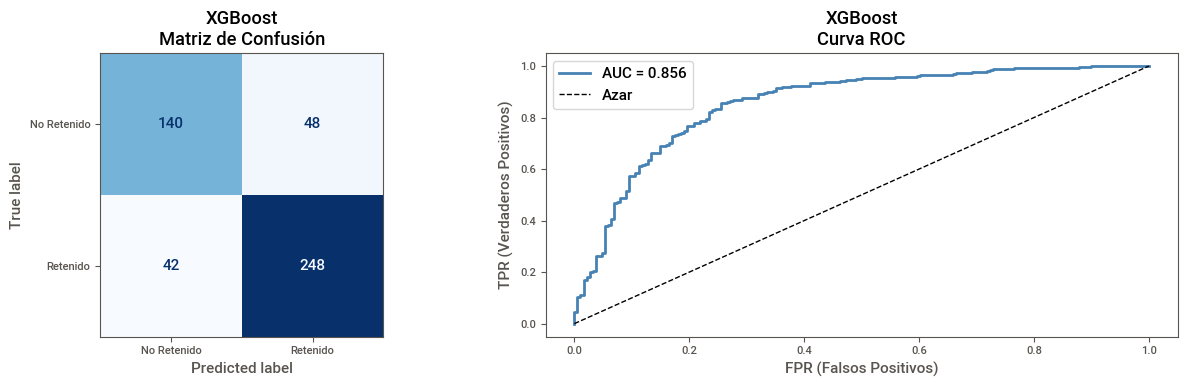

In [29]:
# XGBoost mejora el GBM clásico con:
#   • Regularización L1 (reg_alpha): lleva pesos pequeños a 0 → sparsity
#   • Regularización L2 (reg_lambda): penaliza pesos grandes → suavidad
#   • colsample_bytree: muestreo de features por árbol (como RF)
#   • Manejo nativo de valores nulos
#   • Paralelismo eficiente a nivel de nodo

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,    # Fracción de features por árbol
    reg_alpha=0.1,            # Regularización L1
    reg_lambda=1.0,           # Regularización L2
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb, y_pred_xgb, y_prob_xgb = evaluar_modelo(
    'XGBoost',
    xgb, X_train, y_train, X_test, y_test
)
plot_confusion_roc('XGBoost', y_test, y_pred_xgb, y_prob_xgb)


  LightGBM
  Accuracy       : 0.8013
  ROC-AUC test   : 0.8534
  CV AUC 5-fold  : 0.8573

              precision    recall  f1-score   support

 No Retenido       0.77      0.71      0.74       188
    Retenido       0.82      0.86      0.84       290

    accuracy                           0.80       478
   macro avg       0.79      0.79      0.79       478
weighted avg       0.80      0.80      0.80       478



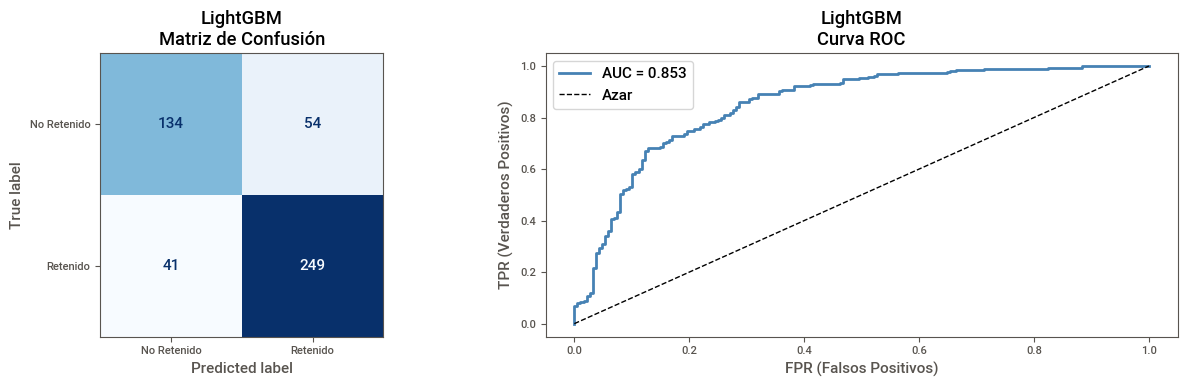

In [30]:
# LightGBM introduce dos innovaciones clave sobre XGBoost:
#   • Crecimiento LEAF-WISE (vs. level-wise de XGBoost):
#     crece la hoja con mayor ganancia, no todas las del mismo nivel.
#     → Árboles más asimétricos, mayor precisión con menos hojas.
#   • GOSS (Gradient-based One-Side Sampling):
#     retiene muestras con gradientes grandes y muestrea las de gradiente pequeño.
#     → Mucho más rápido en datasets grandes.
#   • num_leaves es el hiperparámetro más importante (controla complejidad).

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,            # Máximo de hojas (clave en LightGBM)
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,     # Mínimo de muestras en una hoja
    random_state=42,
    n_jobs=-1,
    verbose=-1                # Silencia los logs internos de entrenamiento
)

lgbm, y_pred_lgbm, y_prob_lgbm = evaluar_modelo(
    'LightGBM',
    lgbm, X_train, y_train, X_test, y_test
)
plot_confusion_roc('LightGBM', y_test, y_pred_lgbm, y_prob_lgbm)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Mejores hiperparámetros XGBoost: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
   Mejor CV AUC: 0.8700

  XGBoost (Optimizado)
  Accuracy       : 0.8075
  ROC-AUC test   : 0.8614
  CV AUC 5-fold  : 0.8677

              precision    recall  f1-score   support

 No Retenido       0.77      0.72      0.75       188
    Retenido       0.83      0.86      0.84       290

    accuracy                           0.81       478
   macro avg       0.80      0.79      0.80       478
weighted avg       0.81      0.81      0.81       478



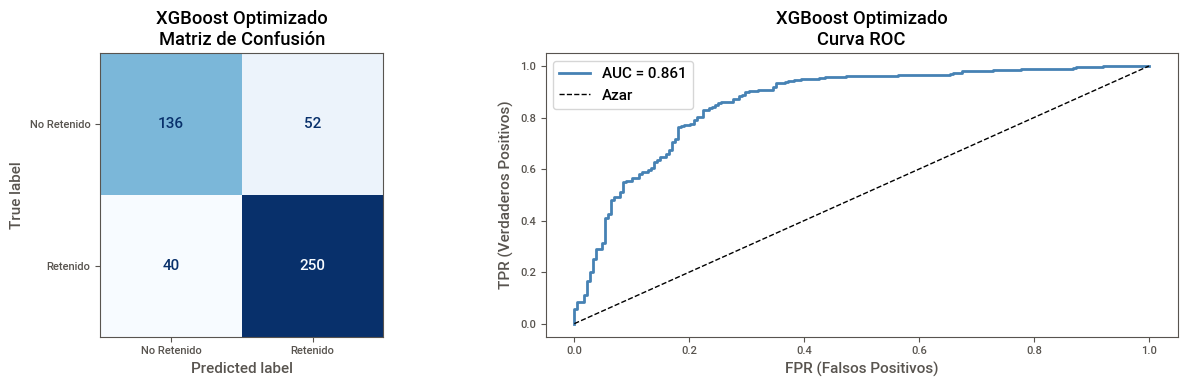

In [31]:
# RandomizedSearchCV no prueba todo el grid sino N combinaciones ALEATORIAS.
# Es preferible a GridSearch cuando el espacio de búsqueda es grande:
# misma calidad de resultado, en mucho menos tiempo.

param_dist_xgb = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [3, 4, 6],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 2.0]
}

rand_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_dist_xgb,
    n_iter=30,          # Prueba 30 combinaciones aleatorias del grid
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rand_xgb.fit(X_train, y_train)

print(f"\n✅ Mejores hiperparámetros XGBoost: {rand_xgb.best_params_}")
print(f"   Mejor CV AUC: {rand_xgb.best_score_:.4f}")

xgb_opt, y_pred_xgbopt, y_prob_xgbopt = evaluar_modelo(
    'XGBoost (Optimizado)',
    rand_xgb.best_estimator_, X_train, y_train, X_test, y_test
)
plot_confusion_roc('XGBoost Optimizado', y_test, y_pred_xgbopt, y_prob_xgbopt)

# Evaluation

In [32]:
# =============================================================================
# FASE 5 — EVALUATION
# Comparamos todos los modelos entrenados usando las métricas acumuladas
# en results_summary a lo largo del notebook.
# =============================================================================

df_results = (
    pd.DataFrame(results_summary)
    .T
    .sort_values('ROC-AUC (test)', ascending=False)
    .round(4)
)
df_results.index.name = 'Modelo'

# Destacamos el mejor en cada métrica
display(
    df_results.style
    .highlight_max(axis=0, color='#2ecc71')   # Verde = mejor
    .highlight_min(axis=0, color='#fadbd8')   # Rojo claro = peor
    .format('{:.4f}')
)

,Accuracy,ROC-AUC (test),CV AUC (5-fold)
Modelo,,,
Random Forest,0.8201,0.8629,0.8641
XGBoost (Optimizado),0.8075,0.8614,0.8677
Random Forest (Optimizado),0.8201,0.8595,0.8669
XGBoost,0.8117,0.8563,0.8639
BaggingClassifier,0.7950,0.8558,0.8570
LightGBM,0.8013,0.8534,0.8573
AdaBoost,0.8054,0.8527,0.8627
Gradient Boosting (GBM),0.7992,0.8520,0.8638
Árbol de Decisión (Baseline),0.7322,0.7120,0.6773


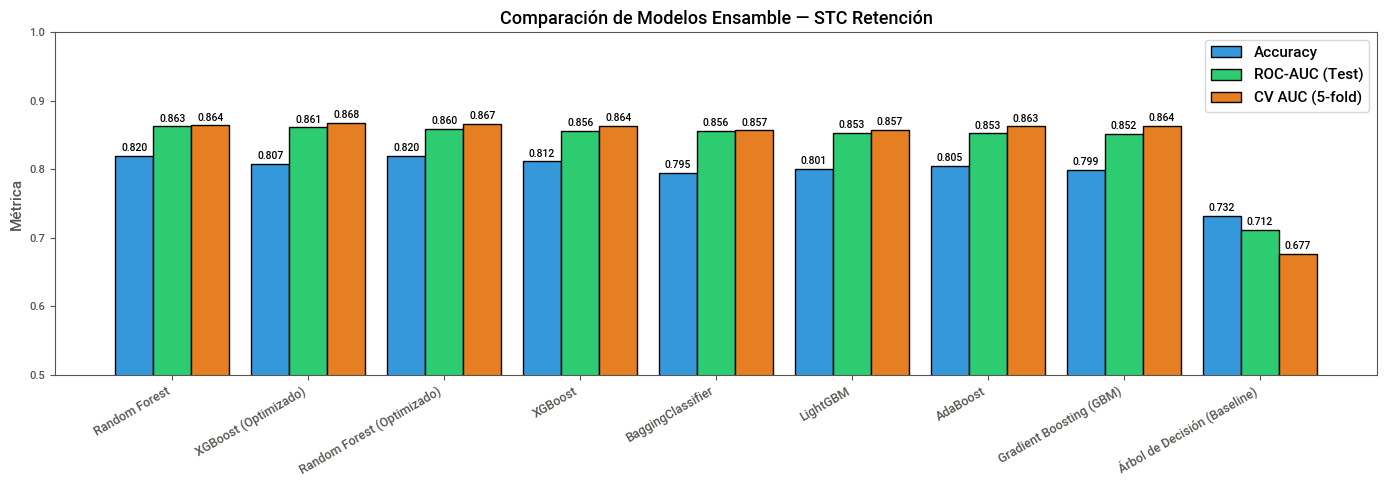

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(df_results))
w = 0.28

ax.bar(x - w, df_results['Accuracy'],        w, label='Accuracy',          color='#3498db', edgecolor='black')
ax.bar(x,     df_results['ROC-AUC (test)'],  w, label='ROC-AUC (Test)',    color='#2ecc71', edgecolor='black')
ax.bar(x + w, df_results['CV AUC (5-fold)'], w, label='CV AUC (5-fold)',   color='#e67e22', edgecolor='black')

# Etiquetas de valor en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7.5, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(df_results.index, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Métrica')
ax.set_title('Comparación de Modelos Ensamble — STC Retención', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

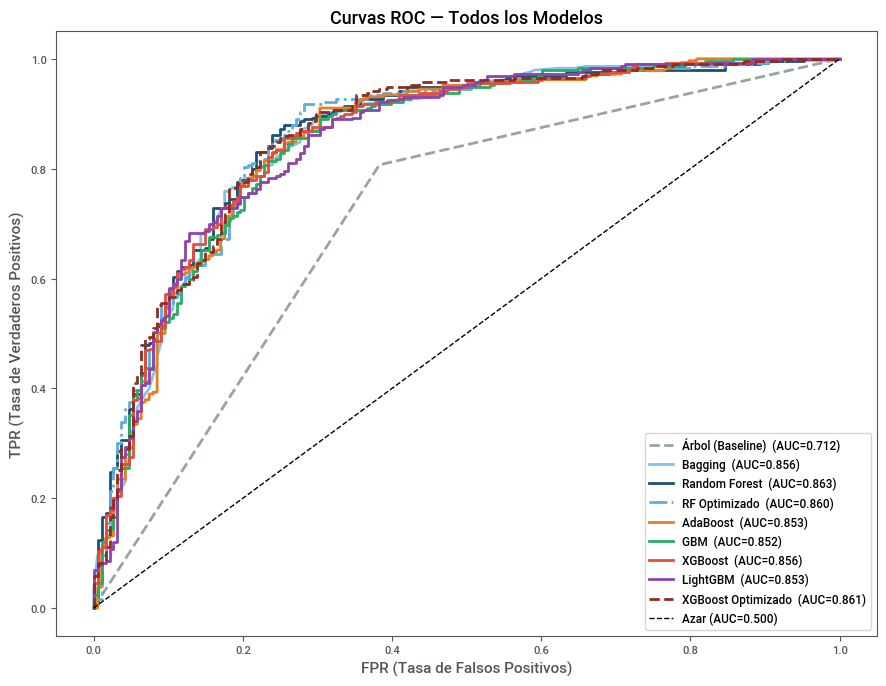

In [34]:
# Comparación visual de la capacidad discriminativa de cada modelo

modelos_roc = {
    'Árbol (Baseline)':   (y_prob_dt,      '#95a5a6', '--'),
    'Bagging':            (y_prob_bag,     '#85c1e9', '-'),
    'Random Forest':      (y_prob_rf,      '#1a5276', '-'),
    'RF Optimizado':      (y_prob_rfopt,   '#5dade2', '-.'),
    'AdaBoost':           (y_prob_ada,     '#e67e22', '-'),
    'GBM':                (y_prob_gbm,     '#27ae60', '-'),
    'XGBoost':            (y_prob_xgb,     '#e74c3c', '-'),
    'LightGBM':           (y_prob_lgbm,    '#8e44ad', '-'),
    'XGBoost Optimizado': (y_prob_xgbopt,  '#922b21', '--'),
}

plt.figure(figsize=(9, 7))
for nombre, (probs, color, ls) in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f'{nombre}  (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC=0.500)')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.title('Curvas ROC — Todos los Modelos', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.show()

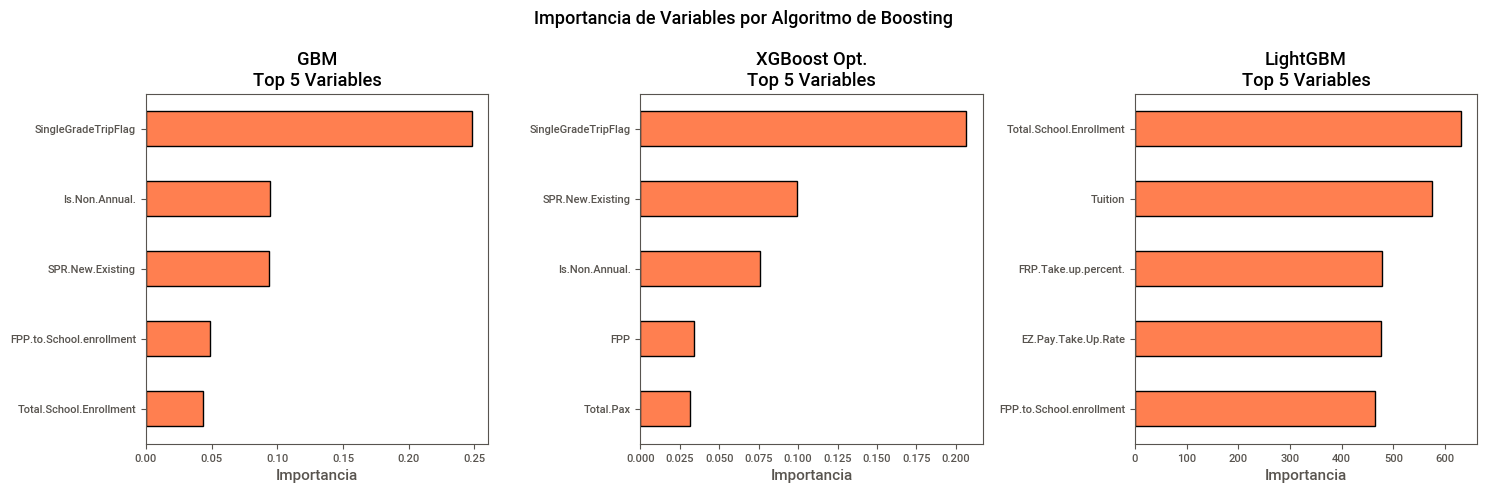

In [38]:
# Comparamos qué variables considera importante cada algoritmo de boosting.
# Si hay consistencia entre los tres → esas variables son verdaderamente relevantes.

fig, axes = plt.subplots(1, 3, figsize=(15,5))
top_n = 5

for ax, (nombre, modelo) in zip(axes, [
    ('GBM',              gbm),
    ('XGBoost Opt.',     xgb_opt),
    ('LightGBM',         lgbm)
]):
    imp = pd.Series(modelo.feature_importances_, index=X_enc.columns)
    imp.nlargest(top_n).sort_values().plot(
        kind='barh', ax=ax, color='coral', edgecolor='black'
    )
    ax.set_title(f'{nombre}\nTop {top_n} Variables', fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Importancia de Variables por Algoritmo de Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Análisis de Overfitting (gap CV vs Test) ===
  Gap > 0.03 puede indicar overfitting significativo

                              CV AUC (5-fold)  ROC-AUC (test)  Gap (CV - Test)
Modelo                                                                        
Gradient Boosting (GBM)                0.8638          0.8520           0.0118
AdaBoost                               0.8627          0.8527           0.0100
XGBoost                                0.8639          0.8563           0.0076
Random Forest (Optimizado)             0.8669          0.8595           0.0074
XGBoost (Optimizado)                   0.8677          0.8614           0.0063
LightGBM                               0.8573          0.8534           0.0039
Random Forest                          0.8641          0.8629           0.0012
BaggingClassifier                      0.8570          0.8558           0.0012
Árbol de Decisión (Baseline)           0.6773          0.7120          -0.0347


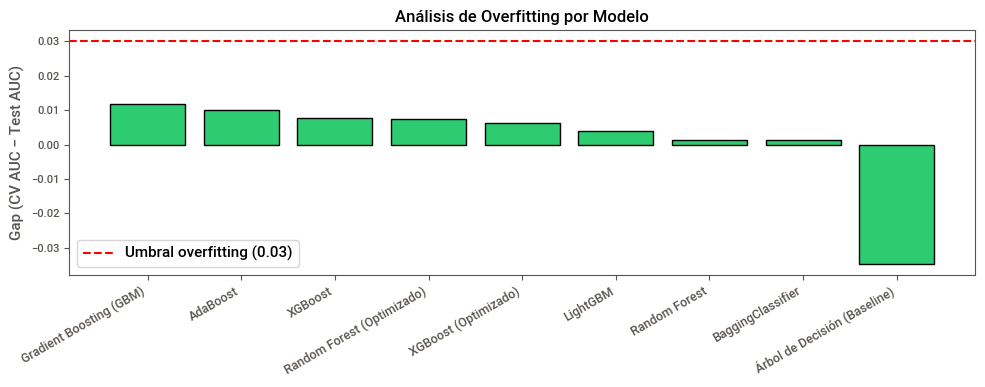

In [40]:
# Comparamos CV AUC (estimación en train) vs ROC-AUC en test.
# Una brecha grande indica OVERFITTING: el modelo memoriza el train
# pero no generaliza bien al test.

df_gap = df_results.copy()
df_gap['Gap (CV - Test)'] = (df_gap['CV AUC (5-fold)'] - df_gap['ROC-AUC (test)']).round(4)
df_gap = df_gap.sort_values('Gap (CV - Test)', ascending=False)

print("=== Análisis de Overfitting (gap CV vs Test) ===")
print("  Gap > 0.03 puede indicar overfitting significativo\n")
print(df_gap[['CV AUC (5-fold)', 'ROC-AUC (test)', 'Gap (CV - Test)']].to_string())

# Visualización del gap
plt.figure(figsize=(10, 4))
colors = ['#e74c3c' if g > 0.03 else '#2ecc71' for g in df_gap['Gap (CV - Test)']]
plt.bar(df_gap.index, df_gap['Gap (CV - Test)'], color=colors, edgecolor='black')
plt.axhline(0.03, color='red', ls='--', lw=1.5, label='Umbral overfitting (0.03)')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylabel('Gap (CV AUC − Test AUC)')
plt.title('Análisis de Overfitting por Modelo', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Deploy

In [41]:
# =============================================================================
# FASE 6 — DEPLOYMENT
# =============================================================================

mejor_modelo = df_results['ROC-AUC (test)'].idxmax()
mejor_auc    = df_results['ROC-AUC (test)'].max()

print("=" * 65)
print("  CONCLUSIONES — Caso STC: Modelado de Retención")
print("=" * 65)

print(f"""
1. MEJOR MODELO: {mejor_modelo}
   ROC-AUC en test: {mejor_auc:.4f}

2. BAGGING vs BOOSTING:
   • Bagging (RF) redujo la varianza del árbol baseline de forma efectiva.
   • Boosting (GBM, XGBoost, LightGBM) obtuvo mejores métricas al
     reducir también el sesgo de forma iterativa.
   • XGBoost y LightGBM destacaron por su regularización L1/L2 incorporada,
     que limita el overfitting sin sacrificar performance.

3. DIFERENCIAS ENTRE ALGORITMOS DE BOOSTING:
   • AdaBoost: el más simple, repondera muestras. Buena interpretabilidad.
   • GBM sklearn: sólido y estable, referencia clásica.
   • XGBoost: añade regularización y paralelismo. Mejor que GBM en este caso.
   • LightGBM: crecimiento leaf-wise, el más rápido de los cuatro.

4. VARIABLES MÁS PREDICTIVAS (consistentes entre modelos):
   • SPR.New.Existing: si el grupo ya había viajado con STC antes.
   • SPR.Group.Revenue / Tuition: valor económico del grupo.
   • FPP / Total.Pax: tamaño del grupo.
   • Days: duración del viaje.
   • NumberOfMeetingswithParents: engagement del organizador.

5. RECOMENDACIÓN PARA STC:
   Desplegar {mejor_modelo} para priorizar campañas de retención.
   Los grupos con probabilidad predicha baja (<40%) deben recibir
   atención personalizada antes del inicio de la temporada de ventas.
""")

  CONCLUSIONES — Caso STC: Modelado de Retención

1. MEJOR MODELO: Random Forest
   ROC-AUC en test: 0.8629

2. BAGGING vs BOOSTING:
   • Bagging (RF) redujo la varianza del árbol baseline de forma efectiva.
   • Boosting (GBM, XGBoost, LightGBM) obtuvo mejores métricas al
     reducir también el sesgo de forma iterativa.
   • XGBoost y LightGBM destacaron por su regularización L1/L2 incorporada,
     que limita el overfitting sin sacrificar performance.

3. DIFERENCIAS ENTRE ALGORITMOS DE BOOSTING:
   • AdaBoost: el más simple, repondera muestras. Buena interpretabilidad.
   • GBM sklearn: sólido y estable, referencia clásica.
   • XGBoost: añade regularización y paralelismo. Mejor que GBM en este caso.
   • LightGBM: crecimiento leaf-wise, el más rápido de los cuatro.

4. VARIABLES MÁS PREDICTIVAS (consistentes entre modelos):
   • SPR.New.Existing: si el grupo ya había viajado con STC antes.
   • SPR.Group.Revenue / Tuition: valor económico del grupo.
   • FPP / Total.Pax: tamaño de